In [1]:
import xarray as xr

import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import glob

fullfiles = sorted(glob.glob("/pub/ranl24/layered_wmb_anomaly_global_gtrend_thetaS/layered_cum_G_global_wmb_anomaly_*.nc"))
#detrendfiles = sorted(glob.glob("/pub/ranl24/layered_wmb_anomaly_global_gtrend_tilde_thetaS/layered_cum_G_global_wmb_anomaly_*.nc"))
detrendfiles = sorted(glob.glob("/pub/ranl24/layered_wmb_anomaly_global_gtrend_tilde_thetaS_gm/layered_cum_G_global_wmb_anomaly_*.nc"))


#full_ds = xr.open_mfdataset(fullfiles).load()
#detrend_ds = xr.open_mfdataset(detrendfiles).load()

len(detrendfiles)

280

In [2]:
import pandas as pd

file = "nina34.data.txt"

df = pd.read_csv(
    file,
    sep=r"\s+",
    header=None
)

df.columns = ['year'] + [f'm{i}' for i in range(1, 13)]

# 转成长时间序列
df_long = df.melt(id_vars='year', var_name='month', value_name='nino34')

# month 转数字
df_long['month'] = df_long['month'].str.extract('(\d+)').astype(int)

# 生成 datetime
df_long['time'] = pd.to_datetime(
    dict(year=df_long['year'], month=df_long['month'], day=1)
)

df_long = df_long.sort_values('time')

print(df_long.head())

     year  month  nino34       time
0    1948      1  -99.99 1948-01-01
79   1948      2  -99.99 1948-02-01
158  1948      3  -99.99 1948-03-01
237  1948      4  -99.99 1948-04-01
316  1948      5  -99.99 1948-05-01


In [3]:
nino34 = xr.DataArray(
    df_long["nino34"].to_numpy(),
    coords={"time": df_long["time"].to_numpy()},
    dims=["time"],
    name="nino34"
)

nino34.attrs["long_name"] = "Niño 3.4 index"
nino34.attrs["units"] = "degC"

In [3]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
import pandas as pd
import matplotlib.ticker as mticker



detrend_ds = xr.open_mfdataset(detrendfiles).load()


# prepare detrend data
detrend_combined = xr.Dataset({
    "g_tend": detrend_ds["g_tend"],
    "g_mix_total": detrend_ds["g_mix_h"] + detrend_ds["g_mix_v"],
    "g_UpTb_total": detrend_ds["g_UpTb_h"] + detrend_ds["g_UpTb_v"],
    "g_UpTp_total": detrend_ds["g_UpTp_h"] + detrend_ds["g_UpTp_v"],
    "g_GM_total": detrend_ds["g_GM_h"] + detrend_ds["g_GM_v"],
    "g_heat": detrend_ds["g_heat"],
    "g_fw": detrend_ds["g_fw"],
    "g_trend": detrend_ds["g_trend"]+detrend_ds["g_Fsatp"],
    "g_Fsstar": detrend_ds["g_Fsstar"],
    #"g_Fsatp":detrend_ds["g_Fsatp"],
    "g_uatp":detrend_ds["g_uatp_h"]+ detrend_ds["g_uatp_v"], 
    "Mass":detrend_ds["Mass"]
})

detrend_rhs_base_vars = [
    "g_mix_total",
    "g_UpTb_total",
    "g_UpTp_total",
    #"g_GM_total",
    "g_heat",
    "g_fw",
    "g_trend",
    "g_Fsstar",
    #"g_Fsatp",
    "g_uatp",
]

detrend_combined["residual"] = (
    detrend_combined["g_tend"]
    - (sum(detrend_combined[v] for v in detrend_rhs_base_vars) )
)

window = 30

detrend_combined_smooth = detrend_combined.rolling(time=window,center=True,).mean()

detrend_mean_ds = detrend_combined_smooth.mean(dim="time")
detrend_std_ds  = detrend_combined_smooth.std(dim="time")

detrend_label_dict = {
    "g_tend": r"$\partial \mathcal{M}/\partial t$",
    "g_mix_total": r"$\mathcal{G}_{\mathrm{mix}}$",
    "g_UpTb_total": r"$\mathcal{G}_{u'\bar{\Theta}}$",
    "g_UpTp_total": r"$\mathcal{G}_{\overline{u'\Theta'}}$",
    "g_GM_total":r"$\mathcal{G}_{GM}$",
    "g_heat": r"$\mathcal{G}_{Q}$",
    "g_fw": r"$\mathcal{G}_{FW}$",
    "g_trend":  r"$\mathcal{G}_{F_{\langle \partial_{t} \Theta \rangle}}$",  #r"$\mathcal{G}_{\langle \partial_{t} \Theta \rangle}+\mathcal{G}_{F_{s^{*}atp1}}$",
    "g_Fsstar": r"$\mathcal{G}_{F_{s^*}}$",
    #"g_Fsatp": r"$\mathcal{G}_{F_{s^{*}atp1}}$",
    "g_uatp": r"$\mathcal{G}_{u(\langle \partial_{t} \Theta \rangle t)'}$",
    "residual": "Residual",
    "Mass":"Mass",
}


# ---- JPO 风格 ----
mpl.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
})

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


In [7]:

detrend_rhs_base_vars = [
    "g_mix_total",
    "g_UpTb_total",
    "g_UpTp_total",
    #"g_GM_total",
    "g_heat",
    "g_fw",
    "g_trend",
    "g_Fsstar",
    #"g_Fsatp",
    "g_uatp",
]

detrend_combined["residual"] = (
    detrend_combined["g_tend"]
    - (sum(detrend_combined[v] for v in detrend_rhs_base_vars) )
)

window = 30

detrend_combined_smooth = detrend_combined.rolling(time=window,center=True,).mean()

detrend_mean_ds = detrend_combined_smooth.mean(dim="time")
detrend_std_ds  = detrend_combined_smooth.std(dim="time")

detrend_label_dict = {
    "g_tend": r"$\partial \mathcal{M}/\partial t$",
    "g_mix_total": r"$\mathcal{G}_{\mathrm{mix}}$",
    "g_UpTb_total": r"$\mathcal{G}_{u'\bar{\Theta}}$",
    "g_UpTp_total": r"$\mathcal{G}_{\overline{u'\Theta'}}$",
    #"g_GM_total":r"$\mathcal{G}_{GM}$",
    "g_heat": r"$\mathcal{G}_{Q}$",
    "g_fw": r"$\mathcal{G}_{FW}$",
    "g_trend":  r"$\mathcal{G}_{F_{\langle \partial_{t} \Theta \rangle}}$",  #r"$\mathcal{G}_{\langle \partial_{t} \Theta \rangle}+\mathcal{G}_{F_{s^{*}atp1}}$",
    "g_Fsstar": r"$\mathcal{G}_{F_{s^*}}$",
    #"g_Fsatp": r"$\mathcal{G}_{F_{s^{*}atp1}}$",
    "g_uatp": r"$\mathcal{G}_{u(\langle \partial_{t} \Theta \rangle t)'}$",
    "residual": "Residual",
    "Mass":"Mass",
}


# ---- JPO 风格 ----
mpl.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
})

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


In [ ]:


target_temp = 3.5

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 6),
    sharex=True,
    gridspec_kw={'hspace': 0.075}
)

# -----------------------------
# (a) Detrended Mass
# -----------------------------
axes[0].plot(
    detrend_combined_smooth.time,
    detrend_combined_smooth["Mass"].sel(tcenter=target_temp, method="nearest")/1e18,
    linewidth=2.5, color="k", alpha=0.8
)
axes[0].axhline(0, linestyle='--', linewidth=1, alpha=0.6)
axes[0].set_ylabel(" ($10^{18}$ kg)")
axes[0].text(0.02, 0.88, "(a) Mass ("+ r"${\tilde{\Theta}}^{\prime} > 3.5^\circ C$"+")", transform=axes[0].transAxes, fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1.5)

# -----------------------------
# (b) Detrended Budget
# -----------------------------
axes[1].plot(
    detrend_combined_smooth.time,
    detrend_combined_smooth["g_tend"].sel(tcenter=target_temp, method="nearest")/1e11,
    linewidth=2.5, color="k", alpha=0.65, label=r"$\partial M/\partial t$"
)
for var in detrend_rhs_base_vars:
    axes[1].plot(
        detrend_combined_smooth.time,
        detrend_combined_smooth[var].sel(tcenter=target_temp, method="nearest")/1e11,
        linewidth=1.2, alpha=0.8, label=detrend_label_dict.get(var, var)
    )
axes[1].plot(
    detrend_combined_smooth.time,
    detrend_combined_smooth["residual"].sel(tcenter=target_temp, method="nearest")/1e11,
    linewidth=1.5, linestyle="--", color="red", alpha=0.65, label="Residual"
)
axes[1].axhline(0, linestyle='--', linewidth=1, alpha=0.6)
axes[1].set_ylabel(" ($10^{11}$ kg/s)")
axes[1].set_ylim(-2, 2)
axes[1].text(0.02, 0.88, "(b) Detrended Anomaly Budget ("+ r"${\tilde{\Theta}}^{\prime} > 3.5^\circ C$"+")", transform=axes[1].transAxes, fontsize=14, fontweight='bold')
axes[1].legend(frameon=False, ncol=6, bbox_to_anchor=(0.05, 0.39), loc='upper left')


In [ ]:


target_temp = 3.5

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 6),
    sharex=True,
    gridspec_kw={'hspace': 0.075}
)

# -----------------------------
# (a) Detrended Mass
# -----------------------------
axes[0].plot(
    detrend_combined_smooth.time,
    detrend_combined_smooth["Mass"].sel(tcenter=target_temp, method="nearest")/1e18,
    linewidth=2.5, color="k", alpha=0.8
)
axes[0].axhline(0, linestyle='--', linewidth=1, alpha=0.6)
axes[0].set_ylabel(" ($10^{18}$ kg)")
axes[0].text(0.02, 0.88, "(a) Mass ("+ r"${\tilde{\Theta}}^{\prime} > 3.5^\circ C$"+")", transform=axes[0].transAxes, fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1.5)

# -----------------------------
# (b) Detrended Budget
# -----------------------------
axes[1].plot(
    detrend_combined_smooth.time,
    detrend_combined_smooth["g_tend"].sel(tcenter=target_temp, method="nearest")/1e11,
    linewidth=2.5, color="k", alpha=0.65, label=r"$\partial M/\partial t$"
)
for var in detrend_rhs_base_vars:
    axes[1].plot(
        detrend_combined_smooth.time,
        detrend_combined_smooth[var].sel(tcenter=target_temp, method="nearest")/1e11,
        linewidth=1.2, alpha=0.8, label=detrend_label_dict.get(var, var)
    )
axes[1].plot(
    detrend_combined_smooth.time,
    detrend_combined_smooth["residual"].sel(tcenter=target_temp, method="nearest")/1e11,
    linewidth=1.5, linestyle="--", color="red", alpha=0.65, label="Residual"
)
axes[1].axhline(0, linestyle='--', linewidth=1, alpha=0.6)
axes[1].set_ylabel(" ($10^{11}$ kg/s)")
axes[1].set_ylim(-2, 2)
axes[1].text(0.02, 0.88, "(b) Detrended Anomaly Budget ("+ r"${\tilde{\Theta}}^{\prime} > 3.5^\circ C$"+")", transform=axes[1].transAxes, fontsize=14, fontweight='bold')
axes[1].legend(frameon=False, ncol=6, bbox_to_anchor=(0.05, 0.39), loc='upper left')


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

data_list = [
    (detrend_mean_ds/1e11, axes[0], detrend_rhs_base_vars, detrend_label_dict, "(a) Detrended mean budget"),
    (detrend_std_ds/1e11,  axes[1], detrend_rhs_base_vars, detrend_label_dict, "(b) Detrended std budget")
]

main_terms = ["g_tend", "residual"]

for data, ax, rhs_vars, label_dict, label_text in data_list:
    ax.plot(data["g_tend"], data["tcenter"],
            linewidth=2.5, color="k", alpha=0.65, label=label_dict["g_tend"])
    
    other_terms = [v for v in rhs_vars if v not in main_terms]
    for var in other_terms:
        ax.plot(data[var], data["tcenter"],
                linewidth=1.2, alpha=0.8, label=label_dict.get(var, var))
    
    ax.plot(data["residual"], data["tcenter"],
            linewidth=1.5, linestyle="--", color="red", alpha=0.65, label=label_dict["residual"])
    
    ax.axvline(0, linewidth=1, alpha=0.6)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.set_ylim(-5., 5.)
    ax.text(0.02, 0.95, label_text, transform=ax.transAxes, fontsize=14, fontweight='bold')

axes[0].set_xlim(-3., 3.)
axes[1].set_xlim(-0.1, 8.)
axes[0].set_xlabel(" ($10^{11}$ kg/s)")
axes[1].set_xlabel(" ($10^{11}$ kg/s)")
axes[0].set_ylabel(r"$\tilde{\Theta}'$ (°C)")

handles, labels = axes[0].get_legend_handles_labels()
axes[1].legend(handles, labels, loc='lower right', ncol=2, frameon=False)

fig.subplots_adjust(left=0.08, right=0.95, top=0.95, bottom=0.08,
                    wspace=0.01, hspace=0.01)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

data_list = [
    (detrend_mean_ds/1e11, axes[0], detrend_rhs_base_vars, detrend_label_dict, "(a) Detrended mean budget"),
    (detrend_std_ds/1e11,  axes[1], detrend_rhs_base_vars, detrend_label_dict, "(b) Detrended std budget")
]

main_terms = ["g_tend", "residual"]

for data, ax, rhs_vars, label_dict, label_text in data_list:
    ax.plot(data["g_tend"], data["tcenter"],
            linewidth=2.5, color="k", alpha=0.65, label=label_dict["g_tend"])
    
    other_terms = [v for v in rhs_vars if v not in main_terms]
    for var in other_terms:
        ax.plot(data[var], data["tcenter"],
                linewidth=1.2, alpha=0.8, label=label_dict.get(var, var))
    
    ax.plot(data["residual"], data["tcenter"],
            linewidth=1.5, linestyle="--", color="red", alpha=0.65, label=label_dict["residual"])
    
    ax.axvline(0, linewidth=1, alpha=0.6)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.set_ylim(-5., 5.)
    ax.text(0.02, 0.95, label_text, transform=ax.transAxes, fontsize=14, fontweight='bold')

axes[0].set_xlim(-3., 3.)
axes[1].set_xlim(-0.1, 8.)
axes[0].set_xlabel(" ($10^{11}$ kg/s)")
axes[1].set_xlabel(" ($10^{11}$ kg/s)")
axes[0].set_ylabel(r"$\tilde{\Theta}'$ (°C)")

handles, labels = axes[0].get_legend_handles_labels()
axes[1].legend(handles, labels, loc='lower right', ncol=2, frameon=False)

fig.subplots_adjust(left=0.08, right=0.95, top=0.95, bottom=0.08,
                    wspace=0.01, hspace=0.01)


In [ ]:
import xarray as xr
import glob

# ======================================
# 1️⃣ 文件列表
# ======================================

fullfiles = sorted(glob.glob(
    "/pub/ranl24/layered_wmb_anomaly_global_gtrend_thetaS/layered_cum_G_global_wmb_anomaly_*.nc"
))

#detrendfiles = sorted(glob.glob(
#    "/pub/ranl24/layered_wmb_anomaly_global_gtrend_tilde_thetaS/layered_cum_G_global_wmb_anomaly_*.nc"
#))
detrendfiles = sorted(glob.glob(
    "/pub/ranl24/layered_wmb_anomaly_global_gtrend_tilde_thetaS_gm/layered_cum_G_global_wmb_anomaly_*.nc"
))

# ======================================
# 2️⃣ 读取 time 维度变量
# ======================================

def preprocess_time(ds):
    # 删除 Mass 和 time_snap（单独处理）
    drop_list = []
    if "Mass" in ds:
        drop_list.append("Mass")
    if "time_snap" in ds:
        drop_list.append("time_snap")
    return ds.drop_vars(drop_list)


full_budget = xr.open_mfdataset(
    fullfiles,
    combine="nested",
    concat_dim="time",
    preprocess=preprocess_time,
    parallel=True,).load()
print("done 1")

detrend_budget = xr.open_mfdataset(
    detrendfiles,
    combine="nested",
    concat_dim="time",
    preprocess=preprocess_time,
    parallel=True,).load()

print("done 2")
# ======================================
# 3️⃣ 单独拼接 Mass（沿 time_snap）
# ======================================

def preprocess_mass(ds):
    if "Mass" in ds:
        ds = ds.isel(time_snap=slice(0, -1))
        return ds[["Mass"]]
    else:
        return ds


full_mass = xr.open_mfdataset(
    fullfiles,
    combine="nested",
    concat_dim="time_snap",
    preprocess=preprocess_mass,
    parallel=True,).load()

print("done 3")

detrend_mass = xr.open_mfdataset(
    detrendfiles,
    combine="nested",
    concat_dim="time_snap",
    preprocess=preprocess_mass,
    parallel=True,).load()

print("done 4")


# ======================================
# 4️⃣ 合并
# ======================================

full_ds = xr.merge([full_budget, full_mass])
detrend_ds = xr.merge([detrend_budget, detrend_mass])


print(full_ds)
print(detrend_ds)


In [3]:

full_ds = xr.merge([full_budget, full_mass])
detrend_ds = xr.merge([detrend_budget, detrend_mass])


print(full_ds)
print(detrend_ds)

<xarray.Dataset> Size: 151MB
Dimensions:    (time: 9130, tcenter: 179, time_snap: 9130)
Coordinates:
  * time       (time) datetime64[ns] 73kB 1993-01-01T12:00:00 ... 2017-12-30T...
  * tcenter    (tcenter) float64 1kB -8.95 -8.849 -8.749 ... 8.749 8.849 8.95
  * time_snap  (time_snap) datetime64[ns] 73kB 1993-01-01T12:00:00 ... 2017-1...
Data variables:
    g_mix_h    (time, tcenter) float64 13MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    g_mix_v    (time, tcenter) float64 13MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    g_heat     (time, tcenter) float64 13MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    g_trend    (time, tcenter) float64 13MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    g_UpTb_h   (time, tcenter) float64 13MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    g_UpTb_v   (time, tcenter) float64 13MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    g_UpTp_h   (time, tcenter) float64 13MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    g_UpTp_v   (time, tcenter) float64 13MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
   

In [8]:
detrend_ds.to_netcdf('/pub/ranl24/layered_wmb_anomaly_global_gtrend_tilde_thetaS.nc')

In [9]:
full_ds.to_netcdf('/pub/ranl24/layered_wmb_anomaly_global_gtrend_thetaS.nc')

# start

In [1]:
import xarray as xr

import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import glob

allfiles=sorted(glob.glob("/pub/ranl24/nino34_daily_index/nino34_daily_temp_profile*.nc") )
nina34= xr.open_mfdataset(allfiles).load()

detrend_ds = xr.open_dataset('/pub/ranl24/layered_wmb_anomaly_global_gtrend_tilde_thetaS.nc')
full_ds    = xr.open_dataset('/pub/ranl24/layered_wmb_anomaly_global_gtrend_thetaS.nc')

In [2]:
window =30
nino = nina34.nino34_temp_anom_profile.isel(k=0)
nino_smooth = nino.rolling(time=window, center=True).mean()

In [3]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
import pandas as pd
import matplotlib.ticker as mticker

# prepare full data

full_combined = xr.Dataset({
    "g_tend": full_ds["g_tend"],
    "g_mix_total": full_ds["g_mix_h"] + full_ds["g_mix_v"],
    "g_UpTb_total": full_ds["g_UpTb_h"] + full_ds["g_UpTb_v"],
    "g_UpTp_total": -full_ds["g_UpTp_h"] - full_ds["g_UpTp_v"],
    "g_heat": full_ds["g_heat"],
    "g_fw": full_ds["g_fw"],
    "g_trend": full_ds["g_trend"],
    "g_Fsstar": full_ds["g_Fsstar"],
    "Mass":full_ds["Mass"].rename({"time_snap":"time"})
})

full_rhs_base_vars = [
    "g_mix_total",
    "g_UpTb_total",
    "g_UpTp_total",
    "g_heat",
    "g_fw",
    "g_trend",
    "g_Fsstar"
]

full_combined["residual"] = (
    full_combined["g_tend"]
    - (sum(full_combined[v] for v in full_rhs_base_vars) )
)

window = 30

full_combined_smooth = full_combined.rolling(time=window,center=True,).mean()

full_mean_ds = full_combined_smooth.mean(dim="time")
full_std_ds  = full_combined_smooth.std(dim="time")

full_label_dict = {
    "g_tend": r"$\partial \mathcal{M}/\partial t$",
    "g_mix_total": r"$\mathcal{G}_{\mathrm{mix}}$",
    "g_UpTb_total": r"$\mathcal{G}_{u'\bar{\Theta}}$",
    "g_UpTp_total": r"$\mathcal{G}_{\overline{u'\Theta'}}$",
    "g_heat": r"$\mathcal{G}_{Q}$",
    "g_fw": r"$\mathcal{S}$",
    "g_trend": r"$\mathcal{G}_{\langle \partial_{t} \Theta \rangle}$",
    "g_Fsstar": r"$\mathcal{G}_{F_{s^*}}$",
    "residual": "Residual",
    "Mass":"Mass",
}


# prepare detrend data
detrend_combined = xr.Dataset({
    "g_tend": detrend_ds["g_tend"],
    "g_mix_total": detrend_ds["g_mix_h"] + detrend_ds["g_mix_v"],
    "g_UpTb_total": detrend_ds["g_UpTb_h"] + detrend_ds["g_UpTb_v"],
    "g_UpTp_total": -detrend_ds["g_UpTp_h"] - detrend_ds["g_UpTp_v"],
    "g_heat": detrend_ds["g_heat"],
    "g_fw": detrend_ds["g_fw"],
    "g_trend": detrend_ds["g_trend"]+detrend_ds["g_Fsatp"],
    "g_Fsstar": detrend_ds["g_Fsstar"],
    #"g_Fsatp":detrend_ds["g_Fsatp"],
    "g_uatp":detrend_ds["g_uatp_h"]+ detrend_ds["g_uatp_v"], 
    "Mass":detrend_ds["Mass"].rename({"time_snap":"time"})
})

detrend_rhs_base_vars = [
    "g_mix_total",
    "g_UpTb_total",
    "g_UpTp_total",
    "g_heat",
    "g_fw",
    "g_trend",
    "g_Fsstar",
    #"g_Fsatp",
    "g_uatp",
]

detrend_combined["residual"] = (
    detrend_combined["g_tend"]
    - (sum(detrend_combined[v] for v in detrend_rhs_base_vars) )
)

window = 30

detrend_combined_smooth = detrend_combined.rolling(time=window,center=True,).mean()

detrend_mean_ds = detrend_combined_smooth.mean(dim="time")
detrend_std_ds  = detrend_combined_smooth.std(dim="time")

detrend_label_dict = {
    "g_tend": r"$\partial \mathcal{M}/\partial t$",
    "g_mix_total": r"$\mathcal{G}_{\mathrm{mix}}$",
    "g_UpTb_total": r"$\mathcal{G}_{u'\bar{\Theta}}$",
    "g_UpTp_total": r"$\mathcal{G}_{\overline{u'\Theta'}}$",
    "g_heat": r"$\mathcal{G}_{Q}$",
    "g_fw": r"$\mathcal{S}$",
    "g_trend":  r"$\mathcal{G}_{F_{\langle \partial_{t} \Theta \rangle}}$",  #r"$\mathcal{G}_{\langle \partial_{t} \Theta \rangle}+\mathcal{G}_{F_{s^{*}atp1}}$",
    "g_Fsstar": r"$\mathcal{G}_{F_{s^*}}$",
    #"g_Fsatp": r"$\mathcal{G}_{F_{s^{*}atp1}}$",
    "g_uatp": r"$\mathcal{G}_{u(\langle \partial_{t} \Theta \rangle t)'}$",
    "residual": "Residual",
    "Mass":"Mass",
}


# ---- JPO 风格 ----
mpl.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
})

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42



In [ ]:
#### figure 5 for jpo

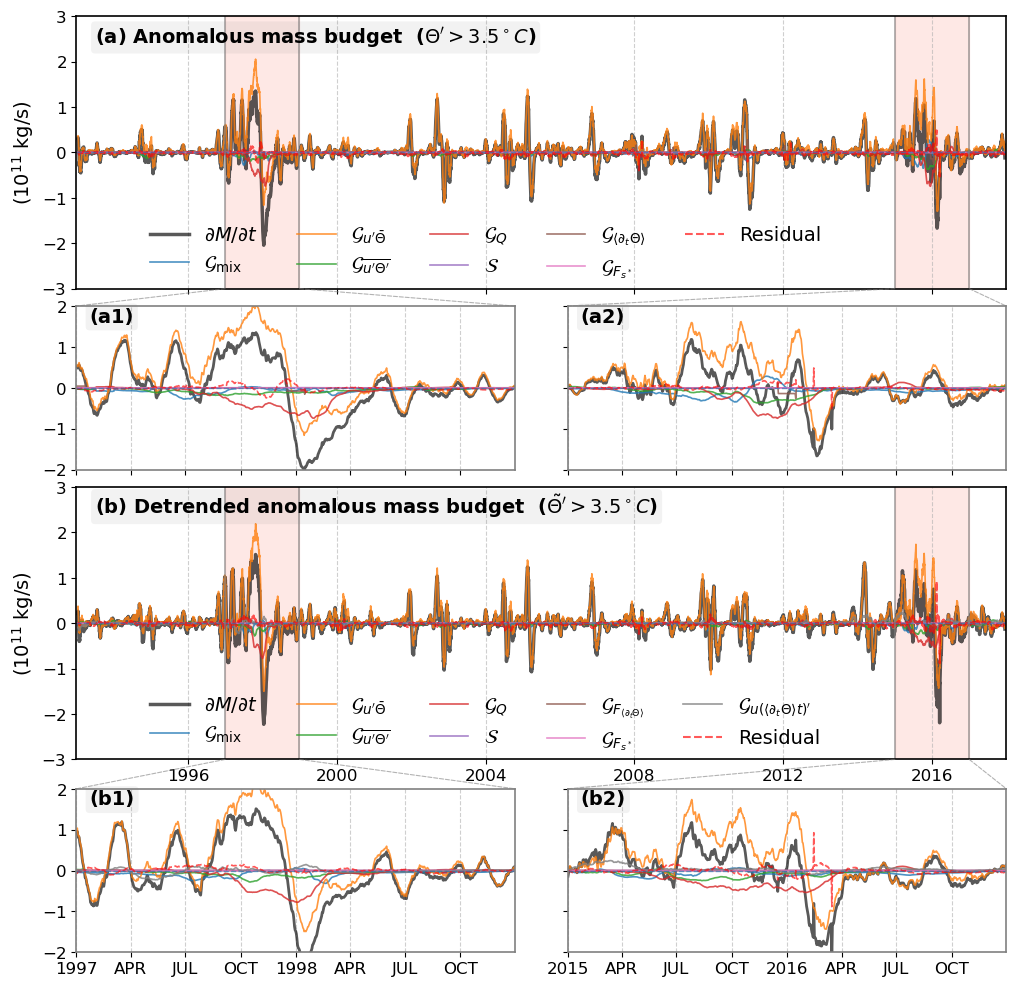

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.patches import ConnectionPatch
import pandas as pd
import numpy as np

# ── 定义两个 zoom 时段 ─────────────────────────────────────────────
period_1 = (np.datetime64("1997-01-01"), np.datetime64("1998-12-31"))
period_2 = (np.datetime64("2015-01-01"), np.datetime64("2016-12-31"))

target_temp = 3.5

SPAN_COLOR = "salmon"
SPAN_ALPHA = 0.18
BOX_COLOR  = "grey"
BOX_LW     = 1.2

# ──────────────────────────────────────────────────────────────────
# GridSpec：4行×2列
#   行0 → (c) Full Budget        跨两列
#   行1 → (c1) zoom P1 | (c2) zoom P2
#   行2 → (d) Detrended Budget   跨两列
#   行3 → (d1) zoom P1 | (d2) zoom P2
# ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 12))
gs  = fig.add_gridspec(
    4, 2,
    height_ratios=[2.5, 1.5, 2.5, 1.5],
    hspace=0.08,
    wspace=0.12,
)

ax_c  = fig.add_subplot(gs[0, :])
ax_c1 = fig.add_subplot(gs[1, 0])
ax_c2 = fig.add_subplot(gs[1, 1])
ax_d  = fig.add_subplot(gs[2, :])
ax_d1 = fig.add_subplot(gs[3, 0])
ax_d2 = fig.add_subplot(gs[3, 1])

# ──────────────────────────────────────────────────────────────────
# 通用函数
# ──────────────────────────────────────────────────────────────────
def plot_budget(ax, ds, rhs_vars, label_dict, title_text):
    ax.plot(
        ds.time,
        ds["g_tend"].sel(tcenter=target_temp, method="nearest") / 1e11,
        linewidth=2.5, color="k", alpha=0.65, label=r"$\partial M/\partial t$"
    )
    for var in rhs_vars:
        ax.plot(
            ds.time,
            ds[var].sel(tcenter=target_temp, method="nearest") / 1e11,
            linewidth=1.2, alpha=0.8, label=label_dict.get(var, var)
        )
    ax.plot(
        ds.time,
        ds["residual"].sel(tcenter=target_temp, method="nearest") / 1e11,
        linewidth=1.5, linestyle="--", color="red", alpha=0.65, label="Residual"
    )
    ax.axhline(0, linestyle="--", linewidth=1, alpha=0.6)
    ax.set_ylim(-3, 3)
    ax.set_ylabel(r"($10^{11}$ kg/s)")
    ax.text(0.02, 0.9, title_text, transform=ax.transAxes,
            fontsize=14, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))


def add_period_spans(ax, periods):
    for (t0, t1) in periods:
        ax.axvspan(t0, t1, color=SPAN_COLOR, alpha=SPAN_ALPHA)
        ax.axvline(t0, color=BOX_COLOR, linewidth=BOX_LW, alpha=0.7)
        ax.axvline(t1, color=BOX_COLOR, linewidth=BOX_LW, alpha=0.7)


def plot_zoom(ax, ds, rhs_vars, label_dict, t0, t1, panel_label):
    ds_zoom = ds.sel(time=slice(t0, t1))
    ax.plot(
        ds_zoom.time,
        ds_zoom["g_tend"].sel(tcenter=target_temp, method="nearest") / 1e11,
        linewidth=2.0, color="k", alpha=0.65
    )
    for var in rhs_vars:
        ax.plot(
            ds_zoom.time,
            ds_zoom[var].sel(tcenter=target_temp, method="nearest") / 1e11,
            linewidth=1.2, alpha=0.8, label=label_dict.get(var, var)
        )
    ax.plot(
        ds_zoom.time,
        ds_zoom["residual"].sel(tcenter=target_temp, method="nearest") / 1e11,
        linewidth=1.2, linestyle="--", color="red", alpha=0.65
    )
    ax.axhline(0, linestyle="--", linewidth=1, alpha=0.6)
    ax.set_ylim(-2, 2)
    ax.set_xlim(t0, t1)
    for spine in ax.spines.values():
        spine.set_edgecolor(BOX_COLOR)
        spine.set_linewidth(1.2)
    ax.text(0.03, 0.9, panel_label, transform=ax.transAxes,
            fontsize=14, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))


def connect_zoom(ax_main, ax_zoom, t0, t1, fig):
    for x_main, x_zoom in [(t0, t0), (t1, t1)]:
        con = ConnectionPatch(
            xyA=(x_main, ax_main.get_ylim()[0]), coordsA=ax_main.transData,
            xyB=(x_zoom, ax_zoom.get_ylim()[1]), coordsB=ax_zoom.transData,
            axesA=ax_main, axesB=ax_zoom,
            color=BOX_COLOR, linewidth=0.8, linestyle="--", alpha=0.6,
            arrowstyle="-",
        )
        fig.add_artist(con)


def fmt_axis(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0, 0))
    ax.yaxis.set_major_formatter(formatter)


# ──────────────────────────────────────────────────────────────────
# (c) Full Budget 主图
# ──────────────────────────────────────────────────────────────────
plot_budget(
    ax_c, full_combined_smooth, full_rhs_base_vars, full_label_dict,
    r"(a) Anomalous mass budget  ($\Theta^\prime > 3.5^\circ C$)")
add_period_spans(ax_c, [period_1, period_2])
ax_c.legend(frameon=False, ncol=5, bbox_to_anchor=(0.06, 0.30), loc="upper left")

# ──────────────────────────────────────────────────────────────────
# (c1) (c2) zoom
# ──────────────────────────────────────────────────────────────────
plot_zoom(ax_c1, full_combined_smooth, full_rhs_base_vars, full_label_dict,
          *period_1, "(a1)")
plot_zoom(ax_c2, full_combined_smooth, full_rhs_base_vars, full_label_dict,
          *period_2, "(a2)")

# ──────────────────────────────────────────────────────────────────
# (d) Detrended Budget 主图
# ──────────────────────────────────────────────────────────────────
plot_budget(
    ax_d, detrend_combined_smooth, detrend_rhs_base_vars, detrend_label_dict,
    r"(b) Detrended anomalous mass budget  (${\tilde{\Theta}}^{\prime} > 3.5^\circ C$)"
)
add_period_spans(ax_d, [period_1, period_2])
ax_d.legend(frameon=False, ncol=5, bbox_to_anchor=(0.06, 0.30), loc="upper left")

# ──────────────────────────────────────────────────────────────────
# (d1) (d2) zoom
# ──────────────────────────────────────────────────────────────────
plot_zoom(ax_d1, detrend_combined_smooth, detrend_rhs_base_vars, detrend_label_dict,
          *period_1, "(b1)")
plot_zoom(ax_d2, detrend_combined_smooth, detrend_rhs_base_vars, detrend_label_dict,
          *period_2, "(b2)")

# ──────────────────────────────────────────────────────────────────
# ConnectionPatch 连线
# ──────────────────────────────────────────────────────────────────
connect_zoom(ax_c, ax_c1, *period_1, fig)
connect_zoom(ax_c, ax_c2, *period_2, fig)
connect_zoom(ax_d, ax_d1, *period_1, fig)
connect_zoom(ax_d, ax_d2, *period_2, fig)

# ──────────────────────────────────────────────────────────────────
# 坐标轴格式：统一应用
# ──────────────────────────────────────────────────────────────────
for ax in [ax_c, ax_c1, ax_c2, ax_d, ax_d1, ax_d2]:
    fmt_axis(ax)

# x 轴标签显示控制
ax_c.tick_params(labelbottom=False)   # c 主图：隐藏
ax_c1.tick_params(labelbottom=False)  # c1：隐藏
ax_c2.tick_params(labelbottom=False)  # c2：隐藏
ax_d.tick_params(labelbottom=True)    # d 主图：显示
#ax_d1.tick_params(labelbottom=False)  # d1：隐藏
#ax_d2.tick_params(labelbottom=False)  # d2：隐藏

# y 轴标签：c2 和 d2 隐藏
ax_c2.tick_params(labelleft=False)
ax_c2.set_ylabel("")
ax_d2.tick_params(labelleft=False)
ax_d2.set_ylabel("")

# d 主图 x 轴标签对齐
for label in ax_d.get_xticklabels():
    label.set_horizontalalignment('center')
    label.set_rotation(0)

# 在所有画图和格式设置完成之后加这几行
# 把 d 主图往上挪一点，和 d1/d2 之间拉开距离

# 同理把 c 主图也往上挪，保持上下对称（可选）
pos_c = ax_d1.get_position()
ax_d1.set_position([pos_c.x0, pos_c.y0 - 0.01, pos_c.width, pos_c.height])
pos_c = ax_d2.get_position()
ax_d2.set_position([pos_c.x0, pos_c.y0 - 0.01, pos_c.width, pos_c.height])

ax_c.set_xlim(full_combined_smooth.time[0], full_combined_smooth.time[-1])
ax_d.set_xlim(full_combined_smooth.time[0], full_combined_smooth.time[-1])

# 在所有 fmt_axis 调用之后，单独覆盖 zoom 子图的 x 轴刻度设置
# for ax in [ax_c1, ax_c2, ax_d1, ax_d2]:
#     ax.xaxis.set_major_locator(mdates.YearLocator(1, month=1, day=1))  # 每年1月1日一个刻度
#     ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))            # 只显示年份
#     ax.tick_params(axis='x', which='major', labelbottom=False)          # 标签仍然隐藏
# ──────────────────────────────────────────────────────────────────

import matplotlib.dates as mdates

# 自定义格式函数
def custom_ym_formatter(x, pos=None):
    dt = mdates.num2date(x)  # 将浮点日期转换为 datetime
    if dt.month == 1:         # 1月显示 YYYYJAN
        return dt.strftime('%Y').upper()
    else:                     # 其它月份只显示缩写
        return dt.strftime('%b').upper()

for ax in [ax_d1, ax_d2]:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))      # 每3个月一个刻度
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(custom_ym_formatter))
    ax.tick_params(axis='x', which='major', labelbottom=True)
    
#fig.savefig("Fig_ecco_twoprime_a_zoom.png",dpi=1000,bbox_inches="tight")
#fig.savefig("Fig_ecco_twoprime_a_zoom.pdf",dpi=1000,bbox_inches="tight",transparent=True)


plt.show()


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


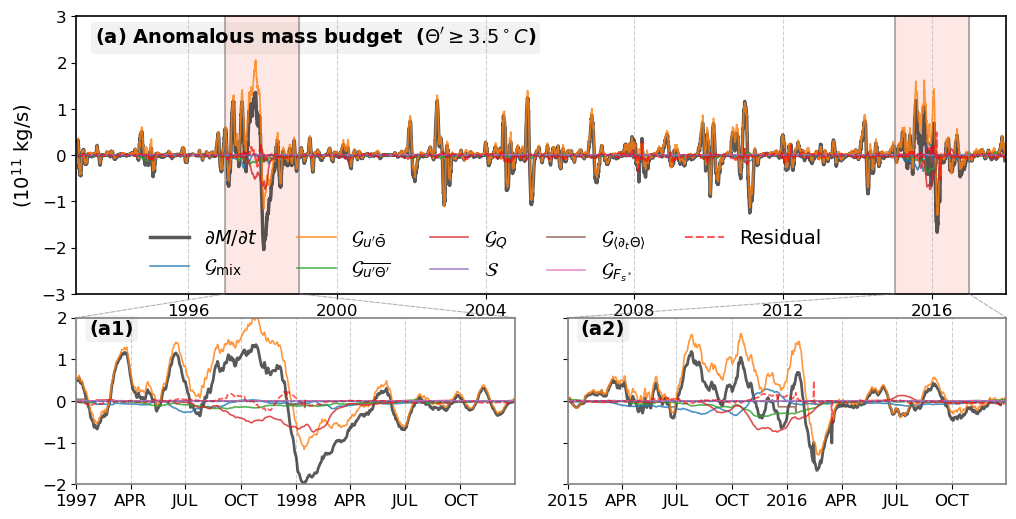

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.patches import ConnectionPatch
import pandas as pd
import numpy as np

# ── 定义两个 zoom 时段 ─────────────────────────────────────────────
period_1 = (np.datetime64("1997-01-01"), np.datetime64("1998-12-31"))
period_2 = (np.datetime64("2015-01-01"), np.datetime64("2016-12-31"))

target_temp = 3.5

SPAN_COLOR = "salmon"
SPAN_ALPHA = 0.18
BOX_COLOR  = "grey"
BOX_LW     = 1.2

# ──────────────────────────────────────────────────────────────────
# GridSpec：2行×2列
#   行0 → (a) Full Budget        跨两列
#   行1 → (a1) zoom P1 | (a2) zoom P2
# ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 6))
gs  = fig.add_gridspec(
    2, 2,
    height_ratios=[2.5, 1.5],
    hspace=0.08,
    wspace=0.12,
)

ax_c  = fig.add_subplot(gs[0, :])
ax_c1 = fig.add_subplot(gs[1, 0])
ax_c2 = fig.add_subplot(gs[1, 1])

# ──────────────────────────────────────────────────────────────────
# 通用函数
# ──────────────────────────────────────────────────────────────────
def plot_budget(ax, ds, rhs_vars, label_dict, title_text):
    ax.plot(
        ds.time,
        ds["g_tend"].sel(tcenter=target_temp, method="nearest") / 1e11,
        linewidth=2.5, color="k", alpha=0.65, label=r"$\partial M/\partial t$"
    )
    for var in rhs_vars:
        ax.plot(
            ds.time,
            ds[var].sel(tcenter=target_temp, method="nearest") / 1e11,
            linewidth=1.2, alpha=0.8, label=label_dict.get(var, var)
        )
    ax.plot(
        ds.time,
        ds["residual"].sel(tcenter=target_temp, method="nearest") / 1e11,
        linewidth=1.5, linestyle="--", color="red", alpha=0.65, label="Residual"
    )
    ax.axhline(0, linestyle="--", linewidth=1, alpha=0.6)
    ax.set_ylim(-3, 3)
    ax.set_ylabel(r"($10^{11}$ kg/s)")
    ax.text(0.02, 0.9, title_text, transform=ax.transAxes,
            fontsize=14, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))


def add_period_spans(ax, periods):
    for (t0, t1) in periods:
        ax.axvspan(t0, t1, color=SPAN_COLOR, alpha=SPAN_ALPHA)
        ax.axvline(t0, color=BOX_COLOR, linewidth=BOX_LW, alpha=0.7)
        ax.axvline(t1, color=BOX_COLOR, linewidth=BOX_LW, alpha=0.7)


def plot_zoom(ax, ds, rhs_vars, label_dict, t0, t1, panel_label):
    ds_zoom = ds.sel(time=slice(t0, t1))
    ax.plot(
        ds_zoom.time,
        ds_zoom["g_tend"].sel(tcenter=target_temp, method="nearest") / 1e11,
        linewidth=2.0, color="k", alpha=0.65
    )
    for var in rhs_vars:
        ax.plot(
            ds_zoom.time,
            ds_zoom[var].sel(tcenter=target_temp, method="nearest") / 1e11,
            linewidth=1.2, alpha=0.8, label=label_dict.get(var, var)
        )
    ax.plot(
        ds_zoom.time,
        ds_zoom["residual"].sel(tcenter=target_temp, method="nearest") / 1e11,
        linewidth=1.2, linestyle="--", color="red", alpha=0.65
    )
    ax.axhline(0, linestyle="--", linewidth=1, alpha=0.6)
    ax.set_ylim(-2, 2)
    ax.set_xlim(t0, t1)
    for spine in ax.spines.values():
        spine.set_edgecolor(BOX_COLOR)
        spine.set_linewidth(1.2)
    ax.text(0.03, 0.9, panel_label, transform=ax.transAxes,
            fontsize=14, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))


def connect_zoom(ax_main, ax_zoom, t0, t1, fig):
    for x_main, x_zoom in [(t0, t0), (t1, t1)]:
        con = ConnectionPatch(
            xyA=(x_main, ax_main.get_ylim()[0]), coordsA=ax_main.transData,
            xyB=(x_zoom, ax_zoom.get_ylim()[1]), coordsB=ax_zoom.transData,
            axesA=ax_main, axesB=ax_zoom,
            color=BOX_COLOR, linewidth=0.8, linestyle="--", alpha=0.6,
            arrowstyle="-",
        )
        fig.add_artist(con)


def fmt_axis(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0, 0))
    ax.yaxis.set_major_formatter(formatter)


# ──────────────────────────────────────────────────────────────────
# (a) Full Budget 主图
# ──────────────────────────────────────────────────────────────────
plot_budget(
    ax_c, full_combined_smooth, full_rhs_base_vars, full_label_dict,
    r"(a) Anomalous mass budget  ($\Theta^\prime \geq 3.5^\circ C$)")
add_period_spans(ax_c, [period_1, period_2])
ax_c.legend(frameon=False, ncol=5, bbox_to_anchor=(0.06, 0.30), loc="upper left")

# ──────────────────────────────────────────────────────────────────
# (a1) (a2) zoom
# ──────────────────────────────────────────────────────────────────
plot_zoom(ax_c1, full_combined_smooth, full_rhs_base_vars, full_label_dict,
          *period_1, "(a1)")
plot_zoom(ax_c2, full_combined_smooth, full_rhs_base_vars, full_label_dict,
          *period_2, "(a2)")

# ──────────────────────────────────────────────────────────────────
# ConnectionPatch 连线
# ──────────────────────────────────────────────────────────────────
connect_zoom(ax_c, ax_c1, *period_1, fig)
connect_zoom(ax_c, ax_c2, *period_2, fig)

# ──────────────────────────────────────────────────────────────────
# 坐标轴格式：统一应用
# ──────────────────────────────────────────────────────────────────
for ax in [ax_c, ax_c1, ax_c2]:
    fmt_axis(ax)

# x 轴标签显示控制
ax_c.tick_params(labelbottom=True)    # a 主图：显示

# y 轴标签：a2 隐藏
ax_c2.tick_params(labelleft=False)
ax_c2.set_ylabel("")

# a 主图 x 轴标签对齐
for label in ax_c.get_xticklabels():
    label.set_horizontalalignment('center')
    label.set_rotation(0)

# 把 zoom 子图往下挪一点，和主图之间拉开距离
pos_c = ax_c1.get_position()
ax_c1.set_position([pos_c.x0, pos_c.y0 - 0.01, pos_c.width, pos_c.height])
pos_c = ax_c2.get_position()
ax_c2.set_position([pos_c.x0, pos_c.y0 - 0.01, pos_c.width, pos_c.height])

ax_c.set_xlim(full_combined_smooth.time[0], full_combined_smooth.time[-1])

# ──────────────────────────────────────────────────────────────────

import matplotlib.dates as mdates

# 自定义格式函数
def custom_ym_formatter(x, pos=None):
    dt = mdates.num2date(x)  # 将浮点日期转换为 datetime
    if dt.month == 1:         # 1月显示 YYYY
        return dt.strftime('%Y').upper()
    else:                     # 其它月份只显示缩写
        return dt.strftime('%b').upper()

for ax in [ax_c1, ax_c2]:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))      # 每3个月一个刻度
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(custom_ym_formatter))
    ax.tick_params(axis='x', which='major', labelbottom=True)

fig.savefig("Fig_ecco_totalprime_a_zoom.png",dpi=1000,bbox_inches="tight")
fig.savefig("Fig_ecco_totalprime_a_zoom.pdf",dpi=1000,bbox_inches="tight",transparent=True)


plt.show()


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


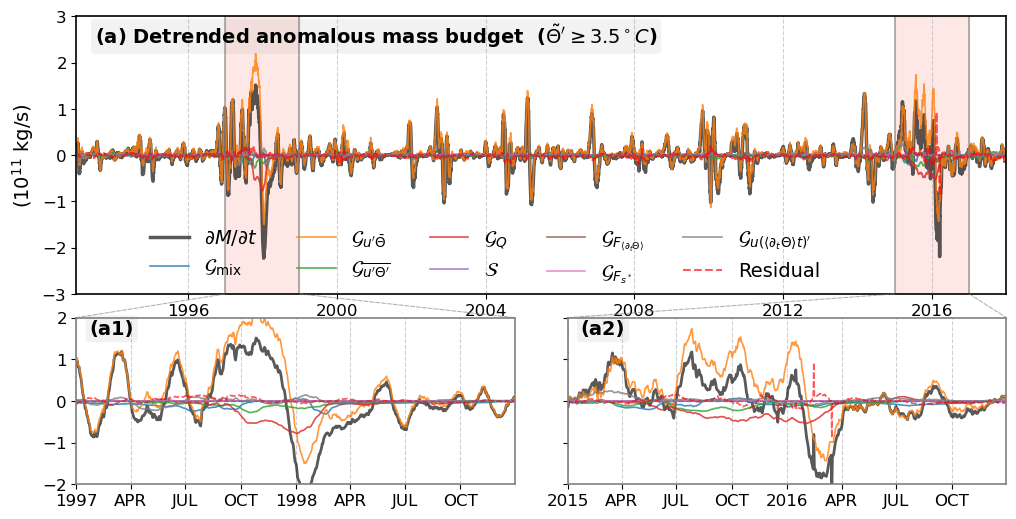

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.patches import ConnectionPatch
import pandas as pd
import numpy as np

# ── 定义两个 zoom 时段 ─────────────────────────────────────────────
period_1 = (np.datetime64("1997-01-01"), np.datetime64("1998-12-31"))
period_2 = (np.datetime64("2015-01-01"), np.datetime64("2016-12-31"))

target_temp = 3.5

SPAN_COLOR = "salmon"
SPAN_ALPHA = 0.18
BOX_COLOR  = "grey"
BOX_LW     = 1.2

# ──────────────────────────────────────────────────────────────────
# GridSpec：2行×2列  (只画 detrended，但面板标号用 a / a1 / a2)
#   行0 → (a) Detrended Budget   跨两列
#   行1 → (a1) zoom P1 | (a2) zoom P2
# ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 6))
gs  = fig.add_gridspec(
    2, 2,
    height_ratios=[2.5, 1.5],
    hspace=0.08,
    wspace=0.12,
)

ax_d  = fig.add_subplot(gs[0, :])
ax_d1 = fig.add_subplot(gs[1, 0])
ax_d2 = fig.add_subplot(gs[1, 1])

# ──────────────────────────────────────────────────────────────────
# 通用函数
# ──────────────────────────────────────────────────────────────────
def plot_budget(ax, ds, rhs_vars, label_dict, title_text):
    ax.plot(
        ds.time,
        ds["g_tend"].sel(tcenter=target_temp, method="nearest") / 1e11,
        linewidth=2.5, color="k", alpha=0.65, label=r"$\partial M/\partial t$"
    )
    for var in rhs_vars:
        ax.plot(
            ds.time,
            ds[var].sel(tcenter=target_temp, method="nearest") / 1e11,
            linewidth=1.2, alpha=0.8, label=label_dict.get(var, var)
        )
    ax.plot(
        ds.time,
        ds["residual"].sel(tcenter=target_temp, method="nearest") / 1e11,
        linewidth=1.5, linestyle="--", color="red", alpha=0.65, label="Residual"
    )
    ax.axhline(0, linestyle="--", linewidth=1, alpha=0.6)
    ax.set_ylim(-3, 3)
    ax.set_ylabel(r"($10^{11}$ kg/s)")
    ax.text(0.02, 0.9, title_text, transform=ax.transAxes,
            fontsize=14, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))


def add_period_spans(ax, periods):
    for (t0, t1) in periods:
        ax.axvspan(t0, t1, color=SPAN_COLOR, alpha=SPAN_ALPHA)
        ax.axvline(t0, color=BOX_COLOR, linewidth=BOX_LW, alpha=0.7)
        ax.axvline(t1, color=BOX_COLOR, linewidth=BOX_LW, alpha=0.7)


def plot_zoom(ax, ds, rhs_vars, label_dict, t0, t1, panel_label):
    ds_zoom = ds.sel(time=slice(t0, t1))
    ax.plot(
        ds_zoom.time,
        ds_zoom["g_tend"].sel(tcenter=target_temp, method="nearest") / 1e11,
        linewidth=2.0, color="k", alpha=0.65
    )
    for var in rhs_vars:
        ax.plot(
            ds_zoom.time,
            ds_zoom[var].sel(tcenter=target_temp, method="nearest") / 1e11,
            linewidth=1.2, alpha=0.8, label=label_dict.get(var, var)
        )
    ax.plot(
        ds_zoom.time,
        ds_zoom["residual"].sel(tcenter=target_temp, method="nearest") / 1e11,
        linewidth=1.2, linestyle="--", color="red", alpha=0.65
    )
    ax.axhline(0, linestyle="--", linewidth=1, alpha=0.6)
    ax.set_ylim(-2, 2)
    ax.set_xlim(t0, t1)
    for spine in ax.spines.values():
        spine.set_edgecolor(BOX_COLOR)
        spine.set_linewidth(1.2)
    ax.text(0.03, 0.9, panel_label, transform=ax.transAxes,
            fontsize=14, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))


def connect_zoom(ax_main, ax_zoom, t0, t1, fig):
    for x_main, x_zoom in [(t0, t0), (t1, t1)]:
        con = ConnectionPatch(
            xyA=(x_main, ax_main.get_ylim()[0]), coordsA=ax_main.transData,
            xyB=(x_zoom, ax_zoom.get_ylim()[1]), coordsB=ax_zoom.transData,
            axesA=ax_main, axesB=ax_zoom,
            color=BOX_COLOR, linewidth=0.8, linestyle="--", alpha=0.6,
            arrowstyle="-",
        )
        fig.add_artist(con)


def fmt_axis(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0, 0))
    ax.yaxis.set_major_formatter(formatter)


# ──────────────────────────────────────────────────────────────────
# (a) Detrended Budget 主图
# ──────────────────────────────────────────────────────────────────
plot_budget(
    ax_d, detrend_combined_smooth, detrend_rhs_base_vars, detrend_label_dict,
    r"(a) Detrended anomalous mass budget  (${\tilde{\Theta}}^{\prime} \geq 3.5^\circ C$)"
    #r"(a) Detrended anomalous mass budget ($\tilde{\Theta}^{\prime} \geq 3.5\,^\circ\mathrm{C}$)"
)
add_period_spans(ax_d, [period_1, period_2])
ax_d.legend(frameon=False, ncol=5, bbox_to_anchor=(0.06, 0.30), loc="upper left")

# ──────────────────────────────────────────────────────────────────
# (a1) (a2) zoom
# ──────────────────────────────────────────────────────────────────
plot_zoom(ax_d1, detrend_combined_smooth, detrend_rhs_base_vars, detrend_label_dict,
          *period_1, "(a1)")
plot_zoom(ax_d2, detrend_combined_smooth, detrend_rhs_base_vars, detrend_label_dict,
          *period_2, "(a2)")

# ──────────────────────────────────────────────────────────────────
# ConnectionPatch 连线
# ──────────────────────────────────────────────────────────────────
connect_zoom(ax_d, ax_d1, *period_1, fig)
connect_zoom(ax_d, ax_d2, *period_2, fig)

# ──────────────────────────────────────────────────────────────────
# 坐标轴格式：统一应用
# ──────────────────────────────────────────────────────────────────
for ax in [ax_d, ax_d1, ax_d2]:
    fmt_axis(ax)

# x 轴标签显示控制
ax_d.tick_params(labelbottom=True)    # a 主图：显示

# y 轴标签：a2 隐藏
ax_d2.tick_params(labelleft=False)
ax_d2.set_ylabel("")

# a 主图 x 轴标签对齐
for label in ax_d.get_xticklabels():
    label.set_horizontalalignment('center')
    label.set_rotation(0)

# 把 zoom 子图往下挪一点，和主图之间拉开距离
pos_c = ax_d1.get_position()
ax_d1.set_position([pos_c.x0, pos_c.y0 - 0.01, pos_c.width, pos_c.height])
pos_c = ax_d2.get_position()
ax_d2.set_position([pos_c.x0, pos_c.y0 - 0.01, pos_c.width, pos_c.height])

ax_d.set_xlim(detrend_combined_smooth.time[0], detrend_combined_smooth.time[-1])

# ──────────────────────────────────────────────────────────────────

import matplotlib.dates as mdates

# 自定义格式函数
def custom_ym_formatter(x, pos=None):
    dt = mdates.num2date(x)  # 将浮点日期转换为 datetime
    if dt.month == 1:         # 1月显示 YYYY
        return dt.strftime('%Y').upper()
    else:                     # 其它月份只显示缩写
        return dt.strftime('%b').upper()

for ax in [ax_d1, ax_d2]:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))      # 每3个月一个刻度
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(custom_ym_formatter))
    ax.tick_params(axis='x', which='major', labelbottom=True)

fig.savefig("Fig_ecco_detrendprime_detrend_a_zoom.png",dpi=1000,bbox_inches="tight")
fig.savefig("Fig_ecco_detrendprime_detrend_a_zoom.pdf",dpi=1000,bbox_inches="tight",transparent=True)


plt.show()


In [ ]:
#### figure 4 for JPO

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


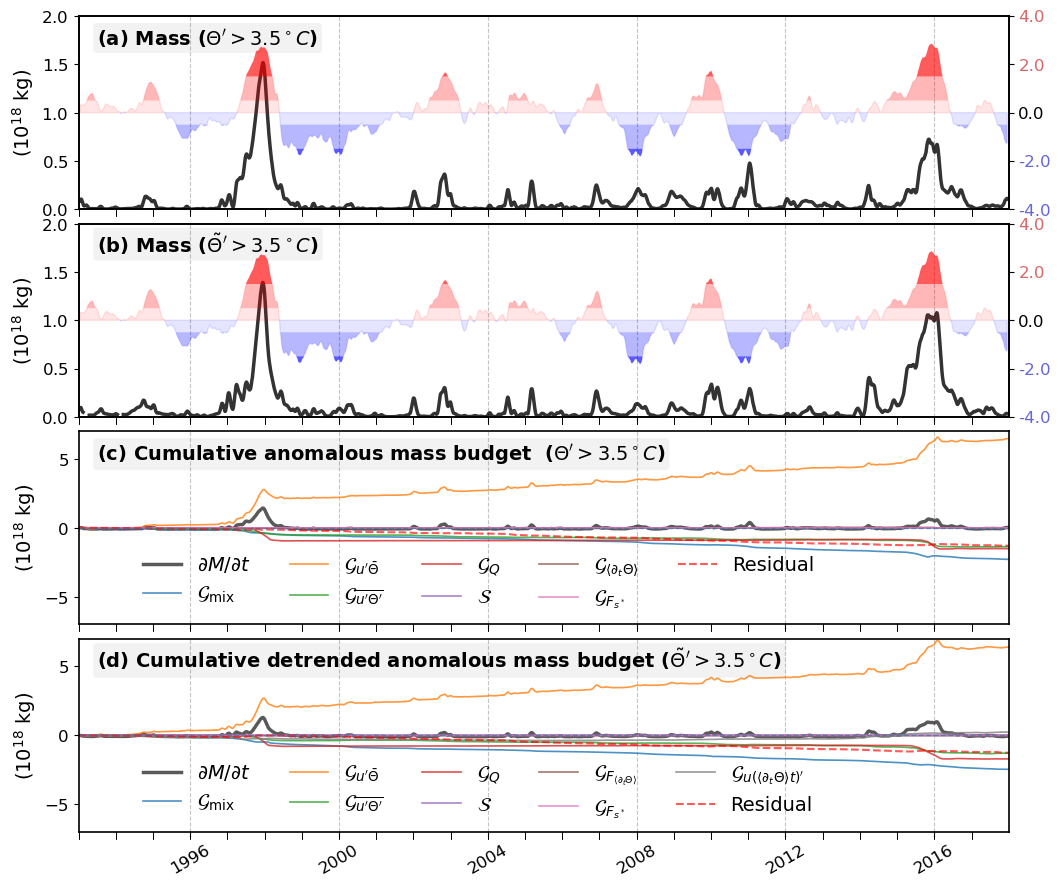

In [41]:
# ------------------------------
# 4行1列子图（累积积分版本）
# ------------------------------
target_temp = 3.5

fig, axes = plt.subplots(
    4, 1,
    figsize=(12, 12),
    sharex=True,
    gridspec_kw={'hspace': 0.075}
)

# 辅助函数：对 DataArray 做时间累积（cumsum），单位转换
def cumsum_var(da, scale):
    """沿 time 维做 cumsum，乘以 dt（秒），再除以 scale"""
    # 计算时间步长（秒）
    time_vals = pd.to_datetime(da.time.values)
    dt_seconds = np.diff(time_vals).astype('timedelta64[s]').astype(float)
    dt_seconds = np.append(dt_seconds, dt_seconds[-1])  # 补最后一个点

    # 转成 xarray DataArray 方便广播
    dt_da = xr.DataArray(dt_seconds, coords={"time": da.time}, dims="time")

    return (da * dt_da).cumsum(dim="time") / scale

# -----------------------------
# (a) Full Mass（保持原样，不做cumsum）
# -----------------------------
axes[0].plot(
    full_combined_smooth.time,
    full_combined_smooth["Mass"].sel(tcenter=target_temp, method="nearest") / 1e18,
    linewidth=2.5, color="k", alpha=0.8
)
axes[0].axhline(0, linestyle='--', linewidth=1, alpha=0.6)
axes[0].set_ylabel("($10^{18}$ kg)")
axes[0].text(0.02, 0.85, "(a) Mass (" + r"$\Theta^\prime > 3.5^\circ C$" + ")",
             transform=axes[0].transAxes, fontsize=14, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))
axes[0].set_ylim(0, 2)

# -----------------------------
# (b) Detrended Mass（保持原样）
# -----------------------------
axes[1].plot(
    detrend_combined_smooth.time,
    detrend_combined_smooth["Mass"].sel(tcenter=target_temp, method="nearest") / 1e18,
    linewidth=2.5, color="k", alpha=0.8
)
axes[1].axhline(0, linestyle='--', linewidth=1, alpha=0.6)
axes[1].set_ylabel("($10^{18}$ kg)")
axes[1].text(0.02, 0.85, "(b) Mass (" + r"${\tilde{\Theta}}^{\prime} > 3.5^\circ C$" + ")",
             transform=axes[1].transAxes, fontsize=14, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))
axes[1].set_ylim(0, 2)

# -----------------------------
# (c) Full Budget — 累积积分
# -----------------------------
scale_c = 1e18  # 累积后单位变成 kg，用 1e18 显示

# g_tend 的累积 ≈ Mass 本身（可作为参考线）
axes[2].plot(
    full_combined_smooth.time,
    cumsum_var(full_combined_smooth["g_tend"].sel(tcenter=target_temp, method="nearest"), scale_c),
    linewidth=2.5, color="k", alpha=0.65, label=r"$\partial M/\partial t$"
)
for var in full_rhs_base_vars:
    axes[2].plot(
        full_combined_smooth.time,
        cumsum_var(full_combined_smooth[var].sel(tcenter=target_temp, method="nearest"), scale_c),
        linewidth=1.2, alpha=0.8, label=full_label_dict.get(var, var)
    )
axes[2].plot(
    full_combined_smooth.time,
    cumsum_var(full_combined_smooth["residual"].sel(tcenter=target_temp, method="nearest"), scale_c),
    linewidth=1.5, linestyle="--", color="red", alpha=0.65, label="Residual"
)
axes[2].axhline(0, linestyle='--', linewidth=1, alpha=0.6)
axes[2].set_ylabel("($10^{18}$ kg)")
axes[2].text(0.02, 0.85, "(c) Cumulative anomalous mass budget  (" + r"$\Theta^\prime > 3.5^\circ C$" + ")",
             transform=axes[2].transAxes, fontsize=14, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))
axes[2].legend(frameon=False, ncol=5, bbox_to_anchor=(0.05, 0.45), loc='upper left')
axes[2].set_ylim(-7,7)

# -----------------------------
# (d) Detrended Budget — 累积积分
# -----------------------------
axes[3].plot(
    detrend_combined_smooth.time,
    cumsum_var(detrend_combined_smooth["g_tend"].sel(tcenter=target_temp, method="nearest"), scale_c),
    linewidth=2.5, color="k", alpha=0.65, label=r"$\partial M/\partial t$"
)
for var in detrend_rhs_base_vars:
    axes[3].plot(
        detrend_combined_smooth.time,
        cumsum_var(detrend_combined_smooth[var].sel(tcenter=target_temp, method="nearest"), scale_c),
        linewidth=1.2, alpha=0.8, label=detrend_label_dict.get(var, var)
    )
axes[3].plot(
    detrend_combined_smooth.time,
    cumsum_var(detrend_combined_smooth["residual"].sel(tcenter=target_temp, method="nearest"), scale_c),
    linewidth=1.5, linestyle="--", color="red", alpha=0.65, label="Residual"
)
axes[3].axhline(0, linestyle='--', linewidth=1, alpha=0.6)
axes[3].set_ylabel("($10^{18}$ kg)")
axes[3].text(0.02, 0.85, "(d) Cumulative detrended anomalous mass budget (" + r"${\tilde{\Theta}}^{\prime} > 3.5^\circ C$" + ")",
             transform=axes[3].transAxes, fontsize=14, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))
axes[3].legend(frameon=False, ncol=5, bbox_to_anchor=(0.05, 0.45), loc='upper left')

# -----------------------------
# 公共设置（与原代码完全相同）
# -----------------------------
axes[3].set_xlim(full_combined_smooth.time[0], full_combined_smooth.time[-1])
axes[3].set_ylim(-7,7)

time_index = pd.to_datetime(full_combined_smooth.time.values)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())

    years = pd.date_range(start=time_index[0], end=time_index[-1], freq='YS')
    years_num = mdates.date2num(years)
    existing_minor = ax.get_xticks(minor=True)
    ax.set_xticks(list(existing_minor) + list(years_num), minor=True)
    ax.tick_params(axis='x', which='minor', length=5)
    ax.tick_params(axis='x', which='minor', labelbottom=False)
    ax.grid(axis='x', linestyle='--', alpha=0.75)

fig.autofmt_xdate()
for ax in axes:
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('center')

for ax in axes:
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0, 0))
    formatter.offset_position = 'left'
    ax.yaxis.set_major_formatter(formatter)




import matplotlib.ticker as mticker

threshold = 0.5

for i, ax in enumerate([axes[0], axes[1]]):

    axr = ax.twinx()

    # =====================
    # 填色（你原来的逻辑）
    # =====================
    axr.fill_between(
        nino_smooth.time,
        0, nino_smooth,
        where=(nino_smooth > 0),
        color='red',
        alpha=0.1,
        interpolate=True
    )

    axr.fill_between(
        nino_smooth.time,
        threshold,
        nino_smooth,
        where=(nino_smooth >= threshold),
        color='red',
        alpha=0.2,
        interpolate=True,
        edgecolor='None',
    )
    axr.fill_between(
        nino_smooth.time,
        1.5,
        nino_smooth,
        where=(nino_smooth >= 1.5),
        color='red',
        alpha=0.5,
        interpolate=True,
        edgecolor='None',
    )

    axr.fill_between(
        nino_smooth.time,
        0, nino_smooth,
        where=(nino_smooth < 0),
        color='blue',
        alpha=0.1,
        interpolate=True
    )
    axr.fill_between(
        nino_smooth.time,
        -threshold,
        nino_smooth,
        where=(nino_smooth <= -threshold),
        color='blue',
        alpha=0.2,
        interpolate=True,
        edgecolor='None',
    )
    axr.fill_between(
        nino_smooth.time,
        -1.5,
        nino_smooth,
        where=(nino_smooth <= -1.5),
        color='blue',
        alpha=0.5,
        interpolate=True,
        edgecolor='None',
    )
    # =====================
    # 轴设置
    # =====================
    axr.set_ylim(-4, 4)
    #axr.set_ylabel("Niño3.4 (°C)")

    # =====================
    # 彩色 tick label（关键）
    # =====================
    def color_ticks(x, pos):
        return f"{x:.1f}"

    axr.yaxis.set_major_formatter(mticker.FuncFormatter(color_ticks))

    # 手动给每个 tick 上色
    for tick, val in zip(axr.get_yticklabels(), axr.get_yticks()):
        if val > 0:
            tick.set_color((0.85, 0.4, 0.4))   # 淡红
        elif val < 0:
            tick.set_color((0.4, 0.4, 0.85))   # 淡蓝
        else:
            tick.set_color("k")
    
    # =====================
    # 优化：只保留一个右轴 label
    # =====================
    if i == 1:
        axr.set_ylabel("")
fig.savefig("Fig_ecco_twoprime_Alltimeseries_cumulative_nino34.png",dpi=1000,bbox_inches="tight")
fig.savefig("Fig_ecco_twoprime_Alltimeseries_cumulative_nino34.pdf",dpi=1000,bbox_inches="tight",transparent=True)

plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


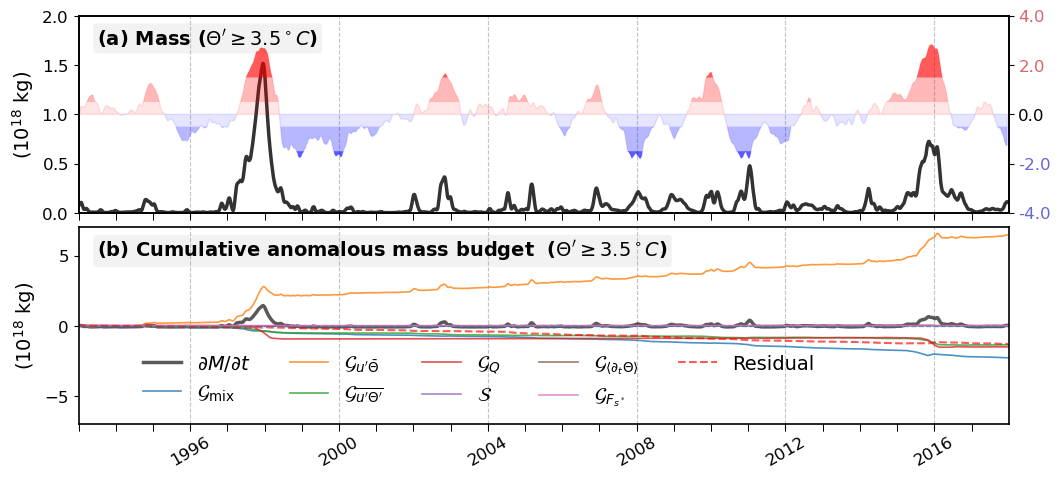

In [10]:
# ------------------------------
# Θ′ 版本：原来的 (a) Mass + (c) 累积收支 → 单独一张图，标号改为 (a)(b)
# ------------------------------
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np
import xarray as xr

target_temp = 3.5

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 6),
    sharex=True,
    gridspec_kw={'hspace': 0.075}
)

# 辅助函数：对 DataArray 做时间累积（cumsum），单位转换
def cumsum_var(da, scale):
    """沿 time 维做 cumsum，乘以 dt（秒），再除以 scale"""
    time_vals = pd.to_datetime(da.time.values)
    dt_seconds = np.diff(time_vals).astype('timedelta64[s]').astype(float)
    dt_seconds = np.append(dt_seconds, dt_seconds[-1])  # 补最后一个点

    dt_da = xr.DataArray(dt_seconds, coords={"time": da.time}, dims="time")

    return (da * dt_da).cumsum(dim="time") / scale

# -----------------------------
# (a) Full Mass（不做 cumsum）
# -----------------------------
axes[0].plot(
    full_combined_smooth.time,
    full_combined_smooth["Mass"].sel(tcenter=target_temp, method="nearest") / 1e18,
    linewidth=2.5, color="k", alpha=0.8
)
axes[0].axhline(0, linestyle='--', linewidth=1, alpha=0.6)
axes[0].set_ylabel("($10^{18}$ kg)")
axes[0].text(0.02, 0.85, "(a) Mass (" + r"$\Theta^\prime \geq 3.5^\circ C$" + ")",
             transform=axes[0].transAxes, fontsize=14, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))
axes[0].set_ylim(0, 2)

# -----------------------------
# (b) Full Budget — 累积积分
# -----------------------------
scale_c = 1e18  # 累积后单位变成 kg，用 1e18 显示

axes[1].plot(
    full_combined_smooth.time,
    cumsum_var(full_combined_smooth["g_tend"].sel(tcenter=target_temp, method="nearest"), scale_c),
    linewidth=2.5, color="k", alpha=0.65, label=r"$\partial M/\partial t$"
)
for var in full_rhs_base_vars:
    axes[1].plot(
        full_combined_smooth.time,
        cumsum_var(full_combined_smooth[var].sel(tcenter=target_temp, method="nearest"), scale_c),
        linewidth=1.2, alpha=0.8, label=full_label_dict.get(var, var)
    )
axes[1].plot(
    full_combined_smooth.time,
    cumsum_var(full_combined_smooth["residual"].sel(tcenter=target_temp, method="nearest"), scale_c),
    linewidth=1.5, linestyle="--", color="red", alpha=0.65, label="Residual"
)
axes[1].axhline(0, linestyle='--', linewidth=1, alpha=0.6)
axes[1].set_ylabel("($10^{18}$ kg)")
axes[1].text(0.02, 0.85, "(b) Cumulative anomalous mass budget  (" + r"$\Theta^\prime \geq 3.5^\circ C$" + ")",
             transform=axes[1].transAxes, fontsize=14, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))
axes[1].legend(frameon=False, ncol=5, bbox_to_anchor=(0.05, 0.45), loc='upper left')
axes[1].set_ylim(-7, 7)

# -----------------------------
# 公共设置
# -----------------------------
axes[1].set_xlim(full_combined_smooth.time[0], full_combined_smooth.time[-1])

time_index = pd.to_datetime(full_combined_smooth.time.values)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())

    years = pd.date_range(start=time_index[0], end=time_index[-1], freq='YS')
    years_num = mdates.date2num(years)
    existing_minor = ax.get_xticks(minor=True)
    ax.set_xticks(list(existing_minor) + list(years_num), minor=True)
    ax.tick_params(axis='x', which='minor', length=5)
    ax.tick_params(axis='x', which='minor', labelbottom=False)
    ax.grid(axis='x', linestyle='--', alpha=0.75)

fig.autofmt_xdate()
for ax in axes:
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('center')

for ax in axes:
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0, 0))
    formatter.offset_position = 'left'
    ax.yaxis.set_major_formatter(formatter)

# -----------------------------
# Niño3.4 背景填色（只加在 Mass 面板上）
# -----------------------------
threshold = 0.5

axr = axes[0].twinx()

axr.fill_between(
    nino_smooth.time, 0, nino_smooth,
    where=(nino_smooth > 0),
    color='red', alpha=0.1, interpolate=True
)
axr.fill_between(
    nino_smooth.time, threshold, nino_smooth,
    where=(nino_smooth >= threshold),
    color='red', alpha=0.2, interpolate=True, edgecolor='None',
)
axr.fill_between(
    nino_smooth.time, 1.5, nino_smooth,
    where=(nino_smooth >= 1.5),
    color='red', alpha=0.5, interpolate=True, edgecolor='None',
)
axr.fill_between(
    nino_smooth.time, 0, nino_smooth,
    where=(nino_smooth < 0),
    color='blue', alpha=0.1, interpolate=True
)
axr.fill_between(
    nino_smooth.time, -threshold, nino_smooth,
    where=(nino_smooth <= -threshold),
    color='blue', alpha=0.2, interpolate=True, edgecolor='None',
)
axr.fill_between(
    nino_smooth.time, -1.5, nino_smooth,
    where=(nino_smooth <= -1.5),
    color='blue', alpha=0.5, interpolate=True, edgecolor='None',
)

axr.set_ylim(-4, 4)

def color_ticks(x, pos):
    return f"{x:.1f}"

axr.yaxis.set_major_formatter(mticker.FuncFormatter(color_ticks))

for tick, val in zip(axr.get_yticklabels(), axr.get_yticks()):
    if val > 0:
        tick.set_color((0.85, 0.4, 0.4))   # 淡红
    elif val < 0:
        tick.set_color((0.4, 0.4, 0.85))   # 淡蓝
    else:
        tick.set_color("k")

fig.savefig("Fig_ecco_totalprime_Mass_cumulative_nino34.png", dpi=1000, bbox_inches="tight")
fig.savefig("Fig_ecco_totalprime_Mass_cumulative_nino34.pdf", dpi=1000, bbox_inches="tight", transparent=True)

plt.show()


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


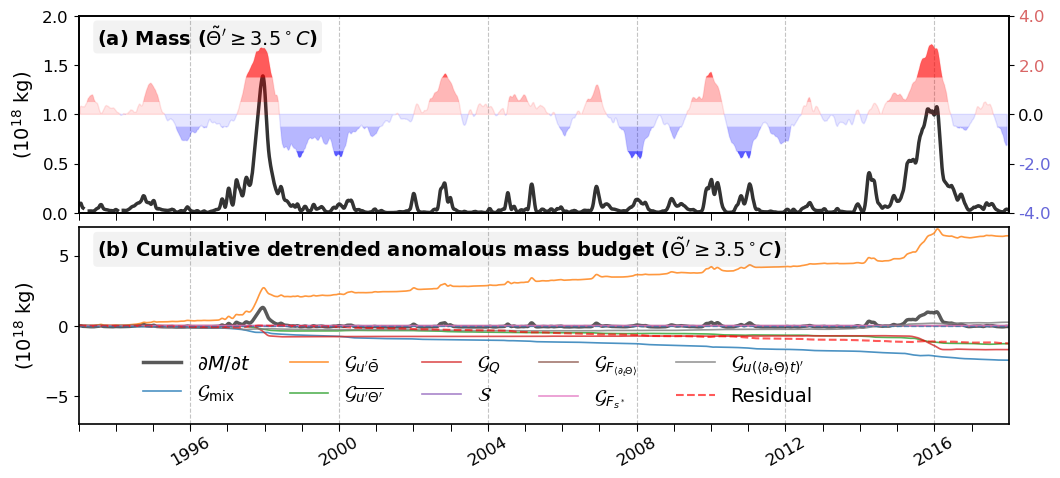

In [11]:
# ------------------------------
# Θ̃′ 版本：原来的 (b) Mass + (d) 累积收支 → 单独一张图，标号改为 (a)(b)
# ------------------------------
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np
import xarray as xr

target_temp = 3.5

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 6),
    sharex=True,
    gridspec_kw={'hspace': 0.075}
)

# 辅助函数：对 DataArray 做时间累积（cumsum），单位转换
def cumsum_var(da, scale):
    """沿 time 维做 cumsum，乘以 dt（秒），再除以 scale"""
    time_vals = pd.to_datetime(da.time.values)
    dt_seconds = np.diff(time_vals).astype('timedelta64[s]').astype(float)
    dt_seconds = np.append(dt_seconds, dt_seconds[-1])  # 补最后一个点

    dt_da = xr.DataArray(dt_seconds, coords={"time": da.time}, dims="time")

    return (da * dt_da).cumsum(dim="time") / scale

# -----------------------------
# (a) Detrended Mass（不做 cumsum）
# -----------------------------
axes[0].plot(
    detrend_combined_smooth.time,
    detrend_combined_smooth["Mass"].sel(tcenter=target_temp, method="nearest") / 1e18,
    linewidth=2.5, color="k", alpha=0.8
)
axes[0].axhline(0, linestyle='--', linewidth=1, alpha=0.6)
axes[0].set_ylabel("($10^{18}$ kg)")
axes[0].text(0.02, 0.85, "(a) Mass (" + r"${\tilde{\Theta}}^{\prime} \geq 3.5^\circ C$" + ")",
             transform=axes[0].transAxes, fontsize=14, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))
axes[0].set_ylim(0, 2)

# -----------------------------
# (b) Detrended Budget — 累积积分
# -----------------------------
scale_c = 1e18  # 累积后单位变成 kg，用 1e18 显示

axes[1].plot(
    detrend_combined_smooth.time,
    cumsum_var(detrend_combined_smooth["g_tend"].sel(tcenter=target_temp, method="nearest"), scale_c),
    linewidth=2.5, color="k", alpha=0.65, label=r"$\partial M/\partial t$"
)
for var in detrend_rhs_base_vars:
    axes[1].plot(
        detrend_combined_smooth.time,
        cumsum_var(detrend_combined_smooth[var].sel(tcenter=target_temp, method="nearest"), scale_c),
        linewidth=1.2, alpha=0.8, label=detrend_label_dict.get(var, var)
    )
axes[1].plot(
    detrend_combined_smooth.time,
    cumsum_var(detrend_combined_smooth["residual"].sel(tcenter=target_temp, method="nearest"), scale_c),
    linewidth=1.5, linestyle="--", color="red", alpha=0.65, label="Residual"
)
axes[1].axhline(0, linestyle='--', linewidth=1, alpha=0.6)
axes[1].set_ylabel("($10^{18}$ kg)")
axes[1].text(0.02, 0.85, "(b) Cumulative detrended anomalous mass budget (" + r"${\tilde{\Theta}}^{\prime} \geq 3.5^\circ C$" + ")",
             transform=axes[1].transAxes, fontsize=14, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))
axes[1].legend(frameon=False, ncol=5, bbox_to_anchor=(0.05, 0.45), loc='upper left')
axes[1].set_ylim(-7, 7)

# -----------------------------
# 公共设置
# -----------------------------
axes[1].set_xlim(detrend_combined_smooth.time[0], detrend_combined_smooth.time[-1])

time_index = pd.to_datetime(detrend_combined_smooth.time.values)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())

    years = pd.date_range(start=time_index[0], end=time_index[-1], freq='YS')
    years_num = mdates.date2num(years)
    existing_minor = ax.get_xticks(minor=True)
    ax.set_xticks(list(existing_minor) + list(years_num), minor=True)
    ax.tick_params(axis='x', which='minor', length=5)
    ax.tick_params(axis='x', which='minor', labelbottom=False)
    ax.grid(axis='x', linestyle='--', alpha=0.75)

fig.autofmt_xdate()
for ax in axes:
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('center')

for ax in axes:
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0, 0))
    formatter.offset_position = 'left'
    ax.yaxis.set_major_formatter(formatter)

# -----------------------------
# Niño3.4 背景填色（只加在 Mass 面板上）
# -----------------------------
threshold = 0.5

axr = axes[0].twinx()

axr.fill_between(
    nino_smooth.time, 0, nino_smooth,
    where=(nino_smooth > 0),
    color='red', alpha=0.1, interpolate=True
)
axr.fill_between(
    nino_smooth.time, threshold, nino_smooth,
    where=(nino_smooth >= threshold),
    color='red', alpha=0.2, interpolate=True, edgecolor='None',
)
axr.fill_between(
    nino_smooth.time, 1.5, nino_smooth,
    where=(nino_smooth >= 1.5),
    color='red', alpha=0.5, interpolate=True, edgecolor='None',
)
axr.fill_between(
    nino_smooth.time, 0, nino_smooth,
    where=(nino_smooth < 0),
    color='blue', alpha=0.1, interpolate=True
)
axr.fill_between(
    nino_smooth.time, -threshold, nino_smooth,
    where=(nino_smooth <= -threshold),
    color='blue', alpha=0.2, interpolate=True, edgecolor='None',
)
axr.fill_between(
    nino_smooth.time, -1.5, nino_smooth,
    where=(nino_smooth <= -1.5),
    color='blue', alpha=0.5, interpolate=True, edgecolor='None',
)

axr.set_ylim(-4, 4)

def color_ticks(x, pos):
    return f"{x:.1f}"

axr.yaxis.set_major_formatter(mticker.FuncFormatter(color_ticks))

for tick, val in zip(axr.get_yticklabels(), axr.get_yticks()):
    if val > 0:
        tick.set_color((0.85, 0.4, 0.4))   # 淡红
    elif val < 0:
        tick.set_color((0.4, 0.4, 0.85))   # 淡蓝
    else:
        tick.set_color("k")

fig.savefig("Fig_ecco_detrendprime_Mass_cumulative_nino34.png", dpi=1000, bbox_inches="tight")
fig.savefig("Fig_ecco_detrendprime_Mass_cumulative_nino34.pdf", dpi=1000, bbox_inches="tight", transparent=True)

plt.show()


In [22]:
mass1 = full_combined_smooth["Mass"].sel(
    tcenter=target_temp, method="nearest"
) / 1e18

nino_smooth = nino.rolling(
    time=window,
    center=True,
    min_periods=window//2
).mean()

# 对齐时间 & 去 NaN
mass1, nino_smooth = xr.align(mass1, nino_smooth, join="inner")
valid = np.isfinite(mass1) & np.isfinite(nino_smooth)

mass1 = mass1.where(valid, drop=True)
nino_smooth = nino_smooth.where(valid, drop=True)

r = xr.corr(mass1, nino_smooth, dim="time")

print("Correlation (r) =", float(r))

Correlation (r) = 0.5763103165664822


In [24]:
mass2 = detrend_combined_smooth["Mass"].sel(
    tcenter=target_temp, method="nearest"
) / 1e18

nino_smooth = nino.rolling(
    time=window,
    center=True,
    min_periods=window//2
).mean()

# 对齐时间 & 去 NaN
mass2, nino_smooth = xr.align(mass2, nino_smooth, join="inner")
valid = np.isfinite(mass2) & np.isfinite(nino_smooth)

mass2 = mass1.where(valid, drop=True)
nino_smooth = nino_smooth.where(valid, drop=True)

r = xr.corr(mass2, nino_smooth, dim="time")

print("Correlation (r) =", float(r))

Correlation (r) = 0.5786703889773264


# figure Mass

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


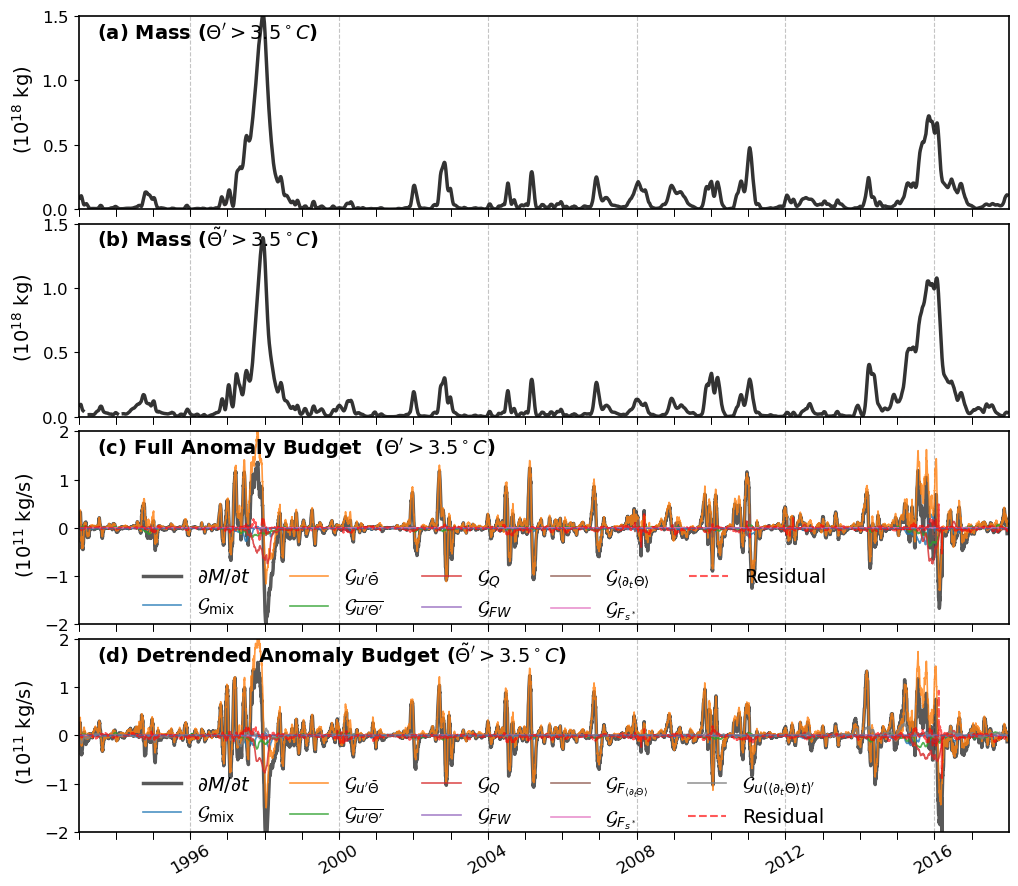

In [9]:
# ------------------------------
# 4行1列子图
# ------------------------------
target_temp = 3.5

fig, axes = plt.subplots(
    4, 1,
    figsize=(12, 12),
    sharex=True,
    gridspec_kw={'hspace': 0.075}  # hspace 越小，子图越紧
)

# -----------------------------
# (a) Full Mass
# -----------------------------
axes[0].plot(
    full_combined_smooth.time,
    full_combined_smooth["Mass"].sel(tcenter=target_temp, method="nearest")/1e18,
    linewidth=2.5, color="k", alpha=0.8
)
axes[0].axhline(0, linestyle='--', linewidth=1, alpha=0.6)
axes[0].set_ylabel(" ($10^{18}$ kg)")
#axes[0].spines['top'].set_visible(False)
#axes[0].spines['right'].set_visible(False)
axes[0].text(0.02, 0.88, "(a) Mass ("+ r"$\Theta^\prime > 3.5^\circ C$"+")", transform=axes[0].transAxes, fontsize=14, fontweight='bold')
axes[0].set_ylim(0,1.5)

# -----------------------------
# (b) Full Budget
# -----------------------------
axes[2].plot(
    full_combined_smooth.time,
    full_combined_smooth["g_tend"].sel(tcenter=target_temp, method="nearest")/1e11,
    linewidth=2.5, color="k", alpha=0.65, label=r"$\partial M/\partial t$"
)
for var in full_rhs_base_vars:
    axes[2].plot(
        full_combined_smooth.time,
        full_combined_smooth[var].sel(tcenter=target_temp, method="nearest")/1e11,
        linewidth=1.2, alpha=0.8, label=full_label_dict.get(var, var)
    )
axes[2].plot(
    full_combined_smooth.time,
    full_combined_smooth["residual"].sel(tcenter=target_temp, method="nearest")/1e11,
    linewidth=1.5, linestyle="--", color="red", alpha=0.65, label="Residual"
)
axes[2].axhline(0, linestyle='--', linewidth=1, alpha=0.6)
axes[2].set_ylabel(" ($10^{11}$ kg/s)")
axes[2].set_ylim(-2, 2)
#axes[2].spines['top'].set_visible(False)
#axes[2].spines['right'].set_visible(False)
axes[2].text(0.02, 0.88, "(c) Full Anomaly Budget  ("+ r"$\Theta^\prime > 3.5^\circ C$"+")", transform=axes[2].transAxes, fontsize=14, fontweight='bold')
axes[2].legend(frameon=False, ncol=5, bbox_to_anchor=(0.05, 0.39), loc='upper left')

# -----------------------------
# (c) Detrended Mass
# -----------------------------
axes[1].plot(
    detrend_combined_smooth.time,
    detrend_combined_smooth["Mass"].sel(tcenter=target_temp, method="nearest")/1e18,
    linewidth=2.5, color="k", alpha=0.8
)
axes[1].axhline(0, linestyle='--', linewidth=1, alpha=0.6)
axes[1].set_ylabel(" ($10^{18}$ kg)")
#axes[1].spines['top'].set_visible(False)
#axes[1].spines['right'].set_visible(False)
axes[1].text(0.02, 0.88, "(b) Mass ("+ r"${\tilde{\Theta}}^{\prime} > 3.5^\circ C$"+")", transform=axes[1].transAxes, fontsize=14, fontweight='bold')
axes[1].set_ylim(0,1.5)

# -----------------------------
# (d) Detrended Budget
# -----------------------------
axes[3].plot(
    detrend_combined_smooth.time,
    detrend_combined_smooth["g_tend"].sel(tcenter=target_temp, method="nearest")/1e11,
    linewidth=2.5, color="k", alpha=0.65, label=r"$\partial M/\partial t$"
)
for var in detrend_rhs_base_vars:
    axes[3].plot(
        detrend_combined_smooth.time,
        detrend_combined_smooth[var].sel(tcenter=target_temp, method="nearest")/1e11,
        linewidth=1.2, alpha=0.8, label=detrend_label_dict.get(var, var)
    )
axes[3].plot(
    detrend_combined_smooth.time,
    detrend_combined_smooth["residual"].sel(tcenter=target_temp, method="nearest")/1e11,
    linewidth=1.5, linestyle="--", color="red", alpha=0.65, label="Residual"
)
axes[3].axhline(0, linestyle='--', linewidth=1, alpha=0.6)
axes[3].set_ylabel(" ($10^{11}$ kg/s)")
axes[3].set_ylim(-2, 2)
#axes[3].spines['top'].set_visible(False)
#axes[3].spines['right'].set_visible(False)
axes[3].text(0.02, 0.88, "(d) Detrended Anomaly Budget ("+ r"${\tilde{\Theta}}^{\prime} > 3.5^\circ C$"+")", transform=axes[3].transAxes, fontsize=14, fontweight='bold')
axes[3].legend(frameon=False, ncol=5, bbox_to_anchor=(0.05, 0.39), loc='upper left')

# -----------------------------
# 公共设置
# -----------------------------
#axes[3].set_xlabel("Time")
axes[3].set_xlim(full_combined_smooth.time[0], full_combined_smooth.time[-1])

# x 轴时间索引
time_index = pd.to_datetime(full_combined_smooth.time.values)

for ax in axes:
    # 自动稀疏显示年份标签
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    
    # 手动画每年的小刻度线，但不显示标签
    years = pd.date_range(start=time_index[0], end=time_index[-1], freq='YS')  # 每年年初
    years_num = mdates.date2num(years)  # 转成 matplotlib date numbers

    # 加入 minor ticks
    existing_minor = ax.get_xticks(minor=True)  # 现有 minor ticks
    ax.set_xticks(list(existing_minor) + list(years_num), minor=True)
    ax.tick_params(axis='x', which='minor', length=5)        # 小刻度长度
    ax.tick_params(axis='x', which='minor', labelbottom=False)  # 不显示标签
    ax.grid(axis='x', linestyle='--', alpha=0.75)

fig.autofmt_xdate()

for ax in axes:
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('center')


for ax in axes:
    # 创建 ScalarFormatter
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0,0))        # 强制科学计数法显示
    formatter.offset_position = 'left'      # 放到纵轴内（旧方法改成属性）
    ax.yaxis.set_major_formatter(formatter)
    
#fig.tight_layout()


fig.savefig("Fig_ecco_twoprime_Alltimeseries.png",dpi=1000,bbox_inches="tight")
fig.savefig("Fig_ecco_twoprime_Alltimeseries.pdf",dpi=1000,bbox_inches="tight",transparent=True)


plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


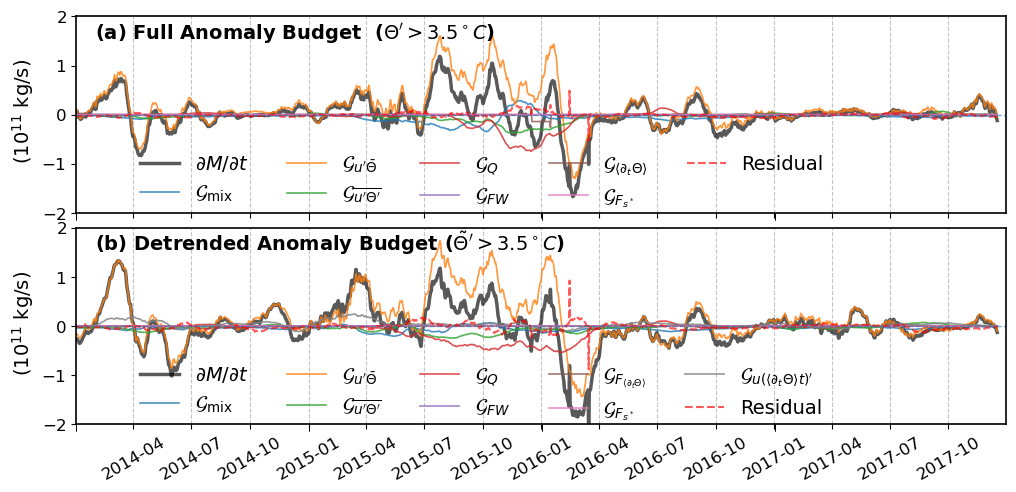

In [23]:
# ------------------------------
# 2行1列子图
# ------------------------------
target_temp = 3.5

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 6),
    sharex=True,
    gridspec_kw={'hspace': 0.075}
)

# -----------------------------
# (c) Full Budget
# -----------------------------
axes[0].plot(
    full_combined_smooth.time,
    full_combined_smooth["g_tend"].sel(tcenter=target_temp, method="nearest")/1e11,
    linewidth=2.5, color="k", alpha=0.65, label=r"$\partial M/\partial t$"
)
for var in full_rhs_base_vars:
    axes[0].plot(
        full_combined_smooth.time,
        full_combined_smooth[var].sel(tcenter=target_temp, method="nearest")/1e11,
        linewidth=1.2, alpha=0.8, label=full_label_dict.get(var, var)
    )
axes[0].plot(
    full_combined_smooth.time,
    full_combined_smooth["residual"].sel(tcenter=target_temp, method="nearest")/1e11,
    linewidth=1.5, linestyle="--", color="red", alpha=0.65, label="Residual"
)
axes[0].axhline(0, linestyle='--', linewidth=1, alpha=0.6)
axes[0].set_ylabel(" ($10^{11}$ kg/s)")
axes[0].set_ylim(-2, 2)
axes[0].text(0.02, 0.88, "(a) Full Anomaly Budget  ("+ r"$\Theta^\prime > 3.5^\circ C$"+")", transform=axes[0].transAxes, fontsize=14, fontweight='bold')
axes[0].legend(frameon=False, ncol=5, bbox_to_anchor=(0.05, 0.39), loc='upper left')

# -----------------------------
# (d) Detrended Budget
# -----------------------------
axes[1].plot(
    detrend_combined_smooth.time,
    detrend_combined_smooth["g_tend"].sel(tcenter=target_temp, method="nearest")/1e11,
    linewidth=2.5, color="k", alpha=0.65, label=r"$\partial M/\partial t$"
)
for var in detrend_rhs_base_vars:
    axes[1].plot(
        detrend_combined_smooth.time,
        detrend_combined_smooth[var].sel(tcenter=target_temp, method="nearest")/1e11,
        linewidth=1.2, alpha=0.8, label=detrend_label_dict.get(var, var)
    )
axes[1].plot(
    detrend_combined_smooth.time,
    detrend_combined_smooth["residual"].sel(tcenter=target_temp, method="nearest")/1e11,
    linewidth=1.5, linestyle="--", color="red", alpha=0.65, label="Residual"
)
axes[1].axhline(0, linestyle='--', linewidth=1, alpha=0.6)
axes[1].set_ylabel(" ($10^{11}$ kg/s)")
axes[1].set_ylim(-2, 2)
axes[1].text(0.02, 0.88, "(b) Detrended Anomaly Budget ("+ r"${\tilde{\Theta}}^{\prime} > 3.5^\circ C$"+")", transform=axes[1].transAxes, fontsize=14, fontweight='bold')
axes[1].legend(frameon=False, ncol=5, bbox_to_anchor=(0.05, 0.39), loc='upper left')

# -----------------------------
# 公共设置
# -----------------------------

time_index = pd.to_datetime(full_combined_smooth.time.values)
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # 每3个月一个主刻度，可按需调整
    
    years = pd.date_range(start=time_index[0], end=time_index[-1], freq='YS')
    years_num = mdates.date2num(years)
    existing_minor = ax.get_xticks(minor=True)
    ax.set_xticks(list(existing_minor) + list(years_num), minor=True)
    ax.tick_params(axis='x', which='minor', length=5)
    ax.tick_params(axis='x', which='minor', labelbottom=False)
    ax.grid(axis='x', linestyle='--', alpha=0.75)
    
fig.autofmt_xdate()

for ax in axes:
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('center')

for ax in axes:
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0,0))
    formatter.offset_position = 'left'
    ax.yaxis.set_major_formatter(formatter)

axes[0].set_xlim(full_combined_smooth.time[-1460], full_combined_smooth.time[-1])
axes[1].set_xlim(full_combined_smooth.time[-1460], full_combined_smooth.time[-1])


fig.savefig("Fig_ecco_twoprime_Alltimeseries_zoomin.png",dpi=1000,bbox_inches="tight")
fig.savefig("Fig_ecco_twoprime_Alltimeseries_zoomin.pdf",dpi=1000,bbox_inches="tight",transparent=True)


plt.show()

In [18]:
full_combined_smooth.time[-1460]

<xarray.DataArray 'time' ()> Size: 8B
array('2014-01-01T12:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2014-01-01T12:00:00

In [ ]:
#### figure 6 for JPO

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


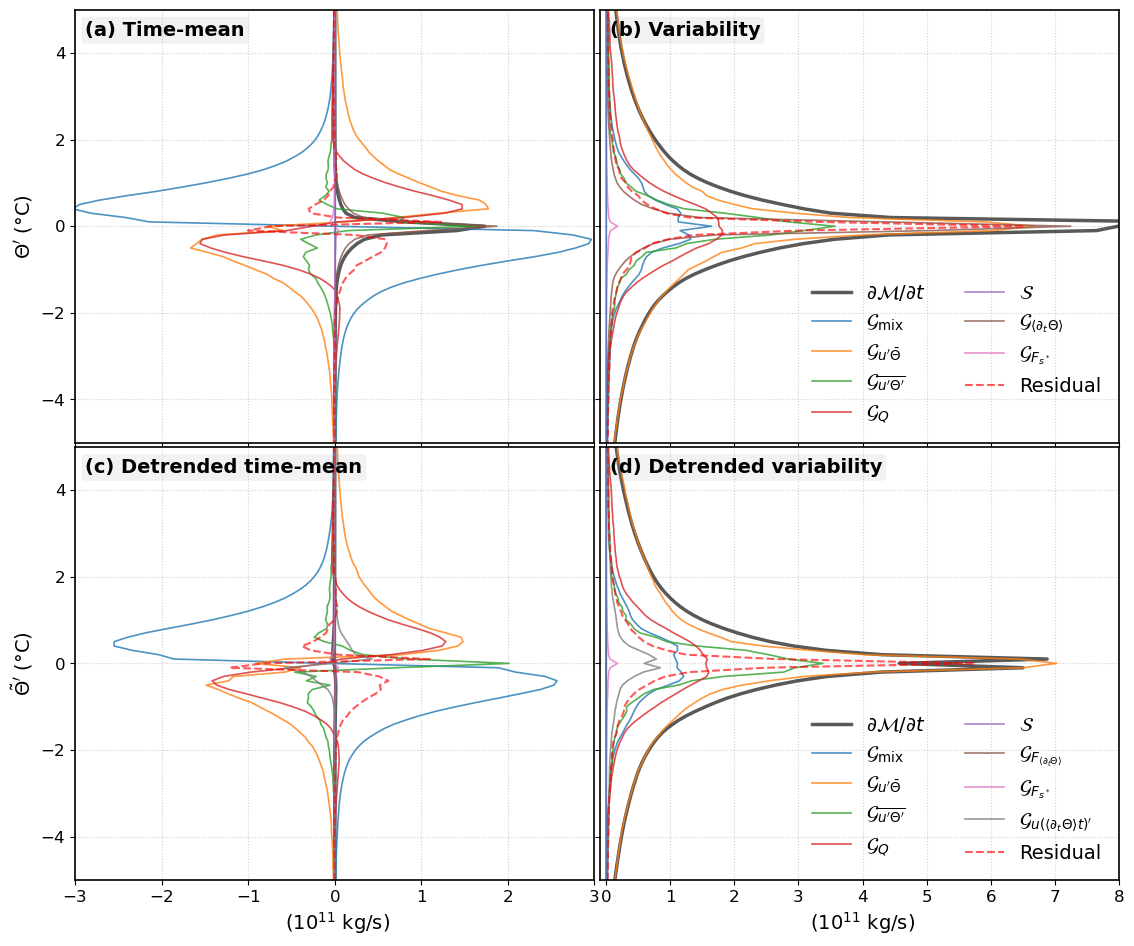

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

# 数据对应顺序
data_list = [
    (full_mean_ds/1e11, axes[0,0], full_rhs_base_vars, full_label_dict, "(a) Time-mean"),
    (full_std_ds/1e11, axes[0,1], full_rhs_base_vars, full_label_dict, "(b) Variability"),
    (detrend_mean_ds/1e11, axes[1,0], detrend_rhs_base_vars, detrend_label_dict, "(c) Detrended time-mean"),
    (detrend_std_ds/1e11, axes[1,1], detrend_rhs_base_vars, detrend_label_dict, "(d) Detrended variability")
]

main_terms = ["g_tend", "residual"]

for data, ax, rhs_vars, label_dict, label_text in data_list:
    # g_tend (黑色粗线)
    ax.plot(data["g_tend"],
            data["tcenter"],
            linewidth=2.5,
            color="k",
            alpha=0.65,
            label=label_dict["g_tend"])
    
    # 其他项（细线 + alpha=0.8）
    other_terms = [v for v in rhs_vars if v not in main_terms]
    for var in other_terms:
        ax.plot(data[var],
                data["tcenter"],
                linewidth=1.2,
                alpha=0.8,
                label=label_dict.get(var, var))
    
    # residual（红色虚线）
    ax.plot(data["residual"],
            data["tcenter"],
            linewidth=1.5,
            linestyle="--",
            color="red",
            alpha=0.65,
            label=label_dict["residual"])
    
    # 美化
    ax.axvline(0, linewidth=1, alpha=0.6)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.set_ylim(-5., 5.)
    
    # 左上角添加 (a)/(b)/(c)/(d) 标注
    ax.text(0.02, 0.94, label_text, transform=ax.transAxes,
            fontsize=14, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))

# x/y label
axes[0,0].set_xlim(-3., 3.)
axes[1,0].set_xlim(-3., 3.)
axes[0,1].set_xlim(-0.1, 8.)
axes[1,1].set_xlim(-0.1, 8.)

axes[1,0].set_xlabel(" ($10^{11}$ kg/s)")
axes[1,1].set_xlabel(" ($10^{11}$ kg/s)")
axes[0,0].set_ylabel(r"$\Theta'$ (°C)")
axes[1,0].set_ylabel(r"$\tilde{\Theta}'$ (°C)")

# legend 统一
handles, labels = axes[0,0].get_legend_handles_labels()
axes[0,1].legend(handles, labels, loc='lower right', ncol=2, frameon=False)

handles, labels = axes[1,0].get_legend_handles_labels()
axes[1,1].legend(handles, labels, loc='lower right', ncol=2, frameon=False)

# 第一行子图不显示横轴ticklabel
for ax in axes[0,:]:
    ax.set_xticklabels([])
    
#fig.tight_layout(rect=[0, 0, 0.95, 1])
fig.subplots_adjust(left=0.08, right=0.95, top=0.95, bottom=0.08,
                    wspace=0.01, hspace=0.01)

# 保存
fig.savefig("Fig_ecco_twoprime_STD_2x2.png", dpi=1000, bbox_inches="tight")
fig.savefig("Fig_ecco_twoprime_STD_2x2.pdf", dpi=1000, bbox_inches="tight", transparent=True)

plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


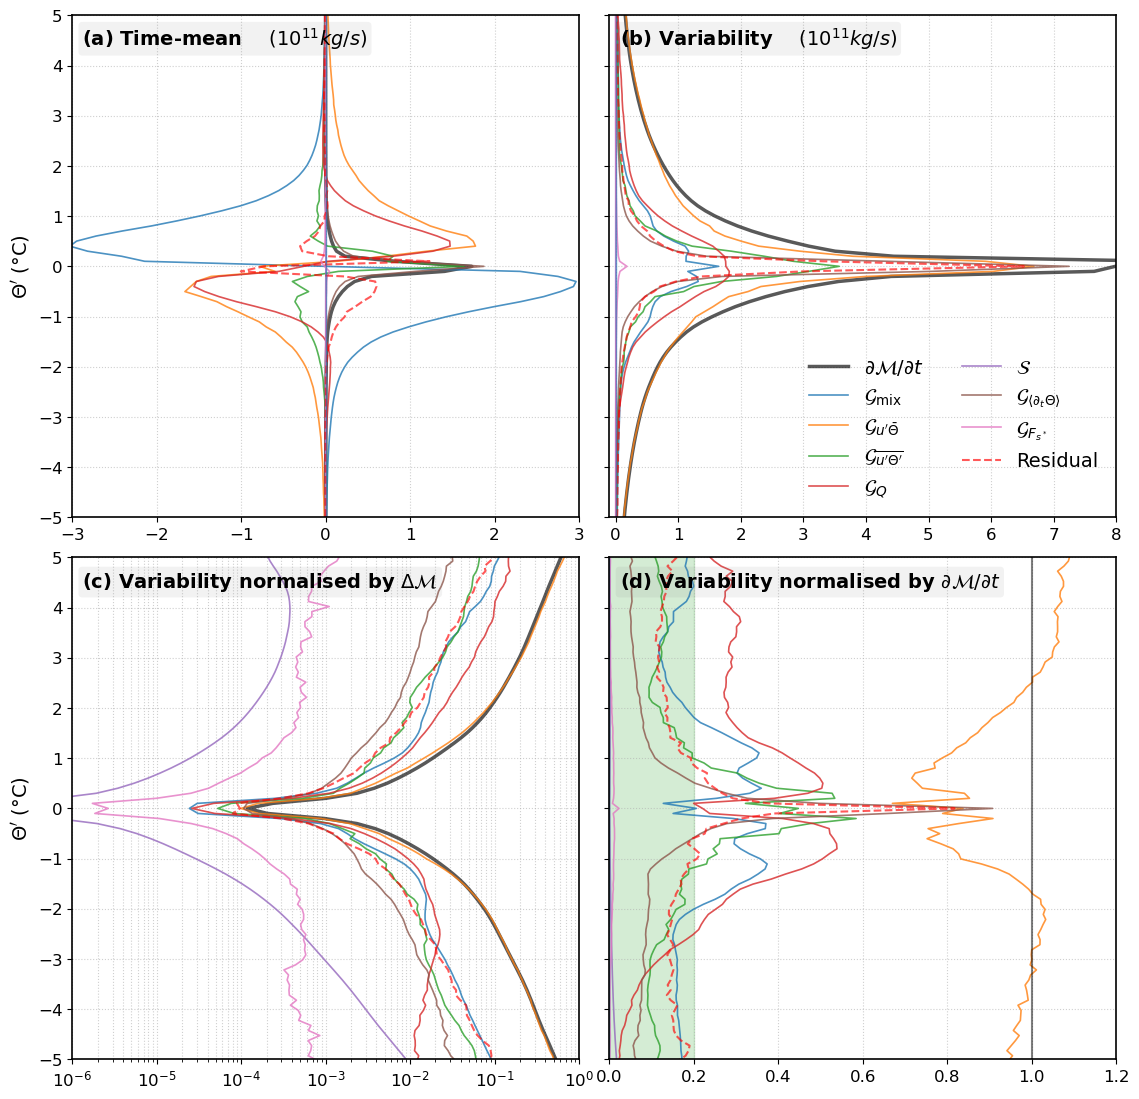

In [58]:
# ------------------------------
# Θ′ 版本 2×2：
#   (a) Time-mean                        (b) Variability
#   (c) Variability normalised by ΔM     (d) Variability normalised by ∂M/∂t
# ------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharey=True)

data_list = [
    (full_mean_ds/1e11, axes[0,0], full_rhs_base_vars, full_label_dict, "(a) Time-mean    "+r"$(10^{11} kg/s)$"),
    (full_std_ds/1e11,  axes[0,1], full_rhs_base_vars, full_label_dict, "(b) Variability    "+r"$(10^{11} kg/s)$"),
]

main_terms = ["g_tend", "residual"]

for data, ax, rhs_vars, label_dict, label_text in data_list:
    # g_tend (黑色粗线)
    ax.plot(data["g_tend"],
            data["tcenter"],
            linewidth=2.5,
            color="k",
            alpha=0.65,
            label=label_dict["g_tend"])

    # 其他项（细线 + alpha=0.8）
    other_terms = [v for v in rhs_vars if v not in main_terms]
    for var in other_terms:
        ax.plot(data[var],
                data["tcenter"],
                linewidth=1.2,
                alpha=0.8,
                label=label_dict.get(var, var))

    # residual（红色虚线）
    ax.plot(data["residual"],
            data["tcenter"],
            linewidth=1.5,
            linestyle="--",
            color="red",
            alpha=0.65,
            label=label_dict["residual"])

    # 美化
    ax.axvline(0, linewidth=1, alpha=0.6)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.set_ylim(-5., 5.)

    # 左上角添加 (a)/(b) 标注
    ax.text(0.02, 0.94, label_text, transform=ax.transAxes,
            fontsize=14, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))

# -----------------------------
# (c) 单位水团质量（无量纲）
#     数据里的 Mass 是累积量 M(Θ′ > tcenter)，先用中心差分
#     [M(i-1) - M(i+1)]/2 转成每一层的质量 ΔM。
#     σ/ΔM 的量纲是 1/s，再乘上参考时间尺度 Δt = 1 day = 86400 s，
#     得到无量纲数：一天之内周转掉的该层质量的比例。
# -----------------------------
ax = axes[1,0]

DT_REF = 86400.   # Δt = 1 day，用来无量纲化

mass_cum   = full_mean_ds["Mass"]
mass_layer = (mass_cum.shift(tcenter=1) - mass_cum.shift(tcenter=-1)) / 2   # 中心差分
mass_layer = mass_layer.where(mass_layer > 0)                               # 避免除以 0 / 负值

per_mass = full_std_ds / mass_layer * DT_REF                                # 无量纲

# g_tend (黑色粗线)
ax.plot(per_mass["g_tend"], per_mass["tcenter"],
        linewidth=2.5, color="k", alpha=0.65,
        label=full_label_dict["g_tend"])

# 其他项（细线 + alpha=0.8），顺序与 (b) 相同 → 配色自动对应
for var in [v for v in full_rhs_base_vars if v not in main_terms]:
    ax.plot(per_mass[var], per_mass["tcenter"],
            linewidth=1.2, alpha=0.8,
            label=full_label_dict.get(var, var))

# residual（红色虚线）
ax.plot(per_mass["residual"], per_mass["tcenter"],
        linewidth=1.5, linestyle="--", color="red", alpha=0.65,
        label=full_label_dict["residual"])

ax.set_xscale("log")          # 跨 ~4 个量级，必须用对数轴
ax.grid(True, linestyle=":", alpha=0.6, which="both")
ax.set_ylim(-5., 5.)
#ax.legend(loc='lower left', frameon=False)
ax.text(0.02, 0.94, r"(c) Variability normalised by $\Delta \mathcal{M}$",
        transform=ax.transAxes,
        fontsize=14, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))

# -----------------------------
# (d) 把 (b) 的各项除以 ∂M/∂t 这一项做归一化（无量纲）
# -----------------------------
ax = axes[1,1]

denom = full_std_ds["g_tend"].where(full_std_ds["g_tend"] > 0)   # 避免除以 0
ratio = full_std_ds / denom                                       # 量纲/系数都被约掉

other_terms = [v for v in full_rhs_base_vars if v not in main_terms]
for var in other_terms:
    ax.plot(ratio[var], ratio["tcenter"],
            linewidth=1.2, alpha=0.8, label=full_label_dict.get(var, var))

ax.plot(ratio["residual"], ratio["tcenter"],
        linewidth=1.5, linestyle="--", color="red", alpha=0.65,
        label=full_label_dict["residual"])

ax.axvline(1, linewidth=1.5, color="k", alpha=0.5, linestyle="-")  # 自身 = 1
ax.axvline(0, linewidth=1, alpha=0.6)
ax.axvspan(0, 0.2, color="tab:green", alpha=0.2)

ax.grid(True, linestyle=":", alpha=0.6)
ax.set_ylim(-5., 5.)
ax.text(0.02, 0.94, r"(d) Variability normalised by $\partial \mathcal{M}/\partial t$",
        transform=ax.transAxes,
        fontsize=14, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))

# -----------------------------
# x/y label 与坐标范围
# -----------------------------
axes[0,0].set_xlim(-3., 3.)
axes[0,1].set_xlim(-0.1, 8.)
axes[1,0].set_xlim(1e-6, 1e0)
axes[1,1].set_xlim(0., 1.2)

#axes[0,0].set_xlabel(" ($10^{11}$ kg/s)")
#axes[0,1].set_xlabel(" ($10^{11}$ kg/s)")
#axes[1,0].set_xlabel(r"$\sigma\,\Delta t\,/\,\Delta \mathcal{M}$   ($\Delta t = 1$ day)")
#axes[1,1].set_xlabel(r"$\sigma\,/\,\sigma_{\partial \mathcal{M}/\partial t}$")
axes[0,0].set_ylabel(r"$\Theta'$ (°C)")
axes[1,0].set_ylabel(r"$\Theta'$ (°C)")

# y 轴刻度：每 1 °C 一个（sharey，所以设一个就够，这里全设一遍更保险）
for ax in axes.flat:
    ax.yaxis.set_major_locator(mticker.MultipleLocator(1))

# legend 统一
handles, labels = axes[0,0].get_legend_handles_labels()
axes[0,1].legend(handles, labels, loc='lower right', ncol=2, frameon=False)

fig.subplots_adjust(left=0.08, right=0.95, top=0.95, bottom=0.08,
                    wspace=0.06, hspace=0.08)

# 保存
fig.savefig("Fig_ecco_totalprime_STD_2x2_norm.png", dpi=1000, bbox_inches="tight")
fig.savefig("Fig_ecco_totalprime_STD_2x2_norm.pdf", dpi=1000, bbox_inches="tight", transparent=True)

plt.show()


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


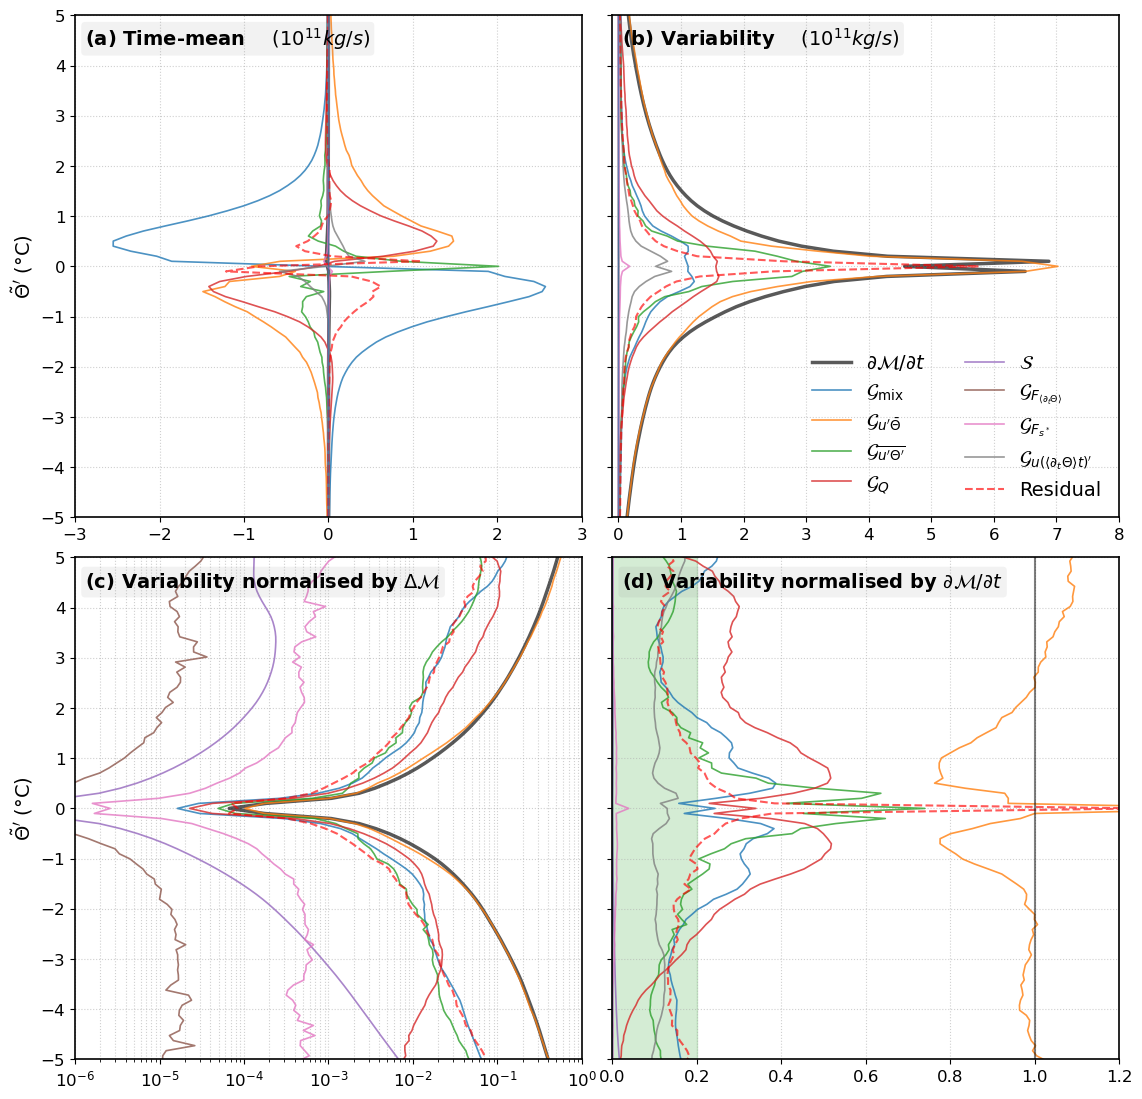

In [63]:
# ------------------------------
# Θ̃′ 版本 2×2：
#   (a) Time-mean                        (b) Variability
#   (c) Variability normalised by ΔM     (d) Variability normalised by ∂M/∂t
# ------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharey=True)

data_list = [
    (detrend_mean_ds/1e11, axes[0,0], detrend_rhs_base_vars, detrend_label_dict, "(a) Time-mean    "+r"$(10^{11} kg/s)$"),
    (detrend_std_ds/1e11,  axes[0,1], detrend_rhs_base_vars, detrend_label_dict, "(b) Variability    "+r"$(10^{11} kg/s)$"),
]


main_terms = ["g_tend", "residual"]

for data, ax, rhs_vars, label_dict, label_text in data_list:
    # g_tend (黑色粗线)
    ax.plot(data["g_tend"],
            data["tcenter"],
            linewidth=2.5,
            color="k",
            alpha=0.65,
            label=label_dict["g_tend"])

    # 其他项（细线 + alpha=0.8）
    other_terms = [v for v in rhs_vars if v not in main_terms]
    for var in other_terms:
        ax.plot(data[var],
                data["tcenter"],
                linewidth=1.2,
                alpha=0.8,
                label=label_dict.get(var, var))

    # residual（红色虚线）
    ax.plot(data["residual"],
            data["tcenter"],
            linewidth=1.5,
            linestyle="--",
            color="red",
            alpha=0.65,
            label=label_dict["residual"])

    # 美化
    ax.axvline(0, linewidth=1, alpha=0.6)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.set_ylim(-5., 5.)

    # 左上角添加 (a)/(b) 标注
    ax.text(0.02, 0.94, label_text, transform=ax.transAxes,
            fontsize=14, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))

# -----------------------------
# (c) 单位水团质量（无量纲）
#     数据里的 Mass 是累积量 M(Θ̃′ > tcenter)，先用中心差分
#     [M(i-1) - M(i+1)]/2 转成每一层的质量 ΔM。
#     σ/ΔM 的量纲是 1/s，再乘上参考时间尺度 Δt = 1 day = 86400 s，
#     得到无量纲数：一天之内周转掉的该层质量的比例。
# -----------------------------
ax = axes[1,0]

DT_REF = 86400.   # Δt = 1 day，用来无量纲化

mass_cum   = detrend_mean_ds["Mass"]
mass_layer = (mass_cum.shift(tcenter=1) - mass_cum.shift(tcenter=-1)) / 2   # 中心差分
mass_layer = mass_layer.where(mass_layer > 0)                               # 避免除以 0 / 负值

per_mass = detrend_std_ds / mass_layer * DT_REF                             # 无量纲

# g_tend (黑色粗线)
ax.plot(per_mass["g_tend"], per_mass["tcenter"],
        linewidth=2.5, color="k", alpha=0.65,
        label=full_label_dict["g_tend"])

# 其他项（细线 + alpha=0.8），顺序与 (b) 相同 → 配色自动对应
for var in [v for v in full_rhs_base_vars if v not in main_terms]:
    ax.plot(per_mass[var], per_mass["tcenter"],
            linewidth=1.2, alpha=0.8,
            label=full_label_dict.get(var, var))

# residual（红色虚线）
ax.plot(per_mass["residual"], per_mass["tcenter"],
        linewidth=1.5, linestyle="--", color="red", alpha=0.65,
        label=full_label_dict["residual"])

ax.set_xscale("log")          # 跨 ~4 个量级，必须用对数轴
ax.grid(True, linestyle=":", alpha=0.6, which="both")
ax.set_ylim(-5., 5.)
#ax.legend(loc='lower left', frameon=False)
ax.text(0.02, 0.94, r"(c) Variability normalised by $\Delta \mathcal{M}$",
        transform=ax.transAxes,
        fontsize=14, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))

# -----------------------------
# (d) 把 (b) 的各项除以 ∂M/∂t 这一项做归一化（无量纲）
# -----------------------------
ax = axes[1,1]

denom = detrend_std_ds["g_tend"].where(detrend_std_ds["g_tend"] > 0)   # 避免除以 0
ratio = detrend_std_ds / denom                                          # 量纲/系数都被约掉

other_terms = [v for v in detrend_rhs_base_vars if v not in main_terms]
for var in other_terms:
    ax.plot(ratio[var], ratio["tcenter"],
            linewidth=1.2, alpha=0.8, label=detrend_label_dict.get(var, var))

ax.plot(ratio["residual"], ratio["tcenter"],
        linewidth=1.5, linestyle="--", color="red", alpha=0.65,
        label=detrend_label_dict["residual"])

ax.axvline(1, linewidth=1.5, color="k", alpha=0.5, linestyle="-")  # 自身 = 1
ax.axvline(0, linewidth=1, alpha=0.6)
ax.axvspan(0, 0.2, color="tab:green", alpha=0.2)

ax.grid(True, linestyle=":", alpha=0.6)
ax.set_ylim(-5., 5.)
ax.text(0.02, 0.94, r"(d) Variability normalised by $\partial \mathcal{M}/\partial t$",
        transform=ax.transAxes,
        fontsize=14, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))

# -----------------------------
# x/y label 与坐标范围
# -----------------------------
axes[0,0].set_xlim(-3., 3.)
axes[0,1].set_xlim(-0.1, 8.)
axes[1,0].set_xlim(1e-6, 1e0)
axes[1,1].set_xlim(0., 1.2)

#axes[0,0].set_xlabel(" ($10^{11}$ kg/s)")
#axes[0,1].set_xlabel(" ($10^{11}$ kg/s)")
#axes[1,0].set_xlabel(r"$\sigma\,\Delta t\,/\,\Delta \mathcal{M}$   ($\Delta t = 1$ day)")
#axes[1,1].set_xlabel(r"$\sigma\,/\,\sigma_{\partial \mathcal{M}/\partial t}$")
axes[0,0].set_ylabel(r"$\tilde{\Theta}'$ (°C)")
axes[1,0].set_ylabel(r"$\tilde{\Theta}'$ (°C)")

# y 轴刻度：每 1 °C 一个（sharey，所以设一个就够，这里全设一遍更保险）
for ax in axes.flat:
    ax.yaxis.set_major_locator(mticker.MultipleLocator(1))

# legend 统一
handles, labels = axes[0,0].get_legend_handles_labels()
axes[0,1].legend(handles, labels, loc='lower right', ncol=2, frameon=False)

fig.subplots_adjust(left=0.08, right=0.95, top=0.95, bottom=0.08,
                    wspace=0.06, hspace=0.08)

# 保存
fig.savefig("Fig_ecco_detrendprime_STD_2x2_norm.png", dpi=1000, bbox_inches="tight")
fig.savefig("Fig_ecco_detrendprime_STD_2x2_norm.pdf", dpi=1000, bbox_inches="tight", transparent=True)

plt.show()


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


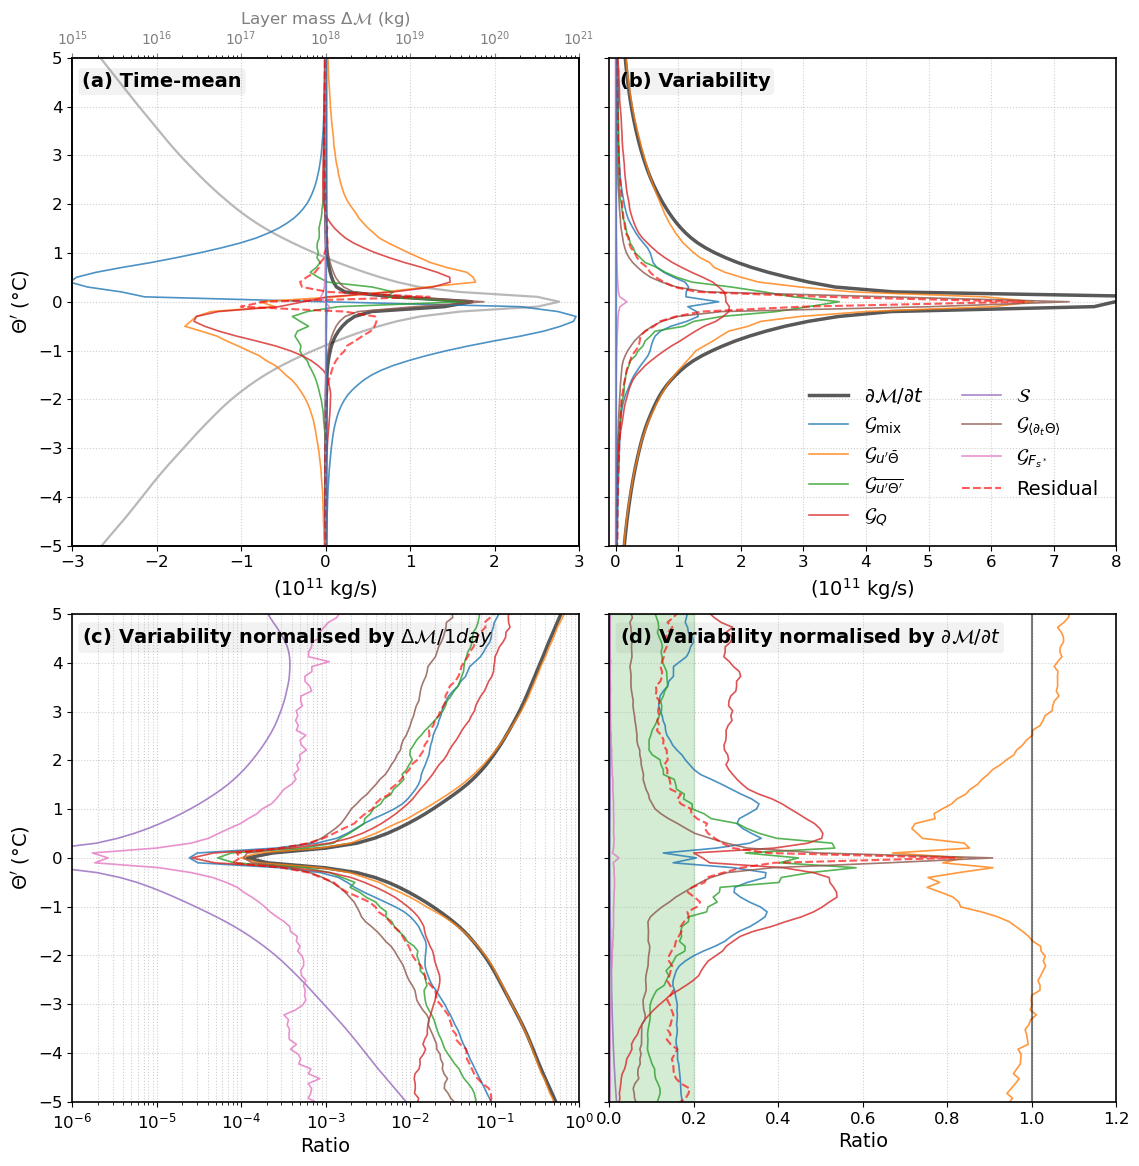

In [14]:
# ------------------------------
# Θ′ 版本 2×2（(a) 顶部叠加 layer mass）：
#   (a) Time-mean + ΔM(顶轴)             (b) Variability
#   (c) Variability normalised by ΔM     (d) Variability normalised by ∂M/∂t
# ------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharey=True)

DT_REF = 86400.   # Δt = 1 day，用来无量纲化

# ---- layer mass 提到最前面算，(a) 和 (c) 共用 ----
#      数据里的 Mass 是累积量 M(Θ′ > tcenter)，中心差分 [M(i-1) - M(i+1)]/2 → 每层质量 ΔM
mass_cum   = full_mean_ds["Mass"]
mass_layer = (mass_cum.shift(tcenter=1) - mass_cum.shift(tcenter=-1)) / 2
mass_layer = mass_layer.where(mass_layer > 0)                # 避免除以 0 / 负值

data_list = [
    (full_mean_ds/1e11, axes[0,0], full_rhs_base_vars, full_label_dict, "(a) Time-mean"),
    (full_std_ds/1e11,  axes[0,1], full_rhs_base_vars, full_label_dict, "(b) Variability"),
]

main_terms = ["g_tend", "residual"]

for data, ax, rhs_vars, label_dict, label_text in data_list:
    # g_tend (黑色粗线)
    ax.plot(data["g_tend"],
            data["tcenter"],
            linewidth=2.5,
            color="k",
            alpha=0.65,
            label=label_dict["g_tend"])

    # 其他项（细线 + alpha=0.8）
    other_terms = [v for v in rhs_vars if v not in main_terms]
    for var in other_terms:
        ax.plot(data[var],
                data["tcenter"],
                linewidth=1.2,
                alpha=0.8,
                label=label_dict.get(var, var))

    # residual（红色虚线）
    ax.plot(data["residual"],
            data["tcenter"],
            linewidth=1.5,
            linestyle="--",
            color="red",
            alpha=0.65,
            label=label_dict["residual"])

    # 美化
    ax.axvline(0, linewidth=1, alpha=0.6)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.set_ylim(-5., 5.)

    # 左上角添加 (a)/(b) 标注
    ax.text(0.02, 0.94, label_text, transform=ax.transAxes,
            fontsize=14, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))

# -----------------------------
# (a) 顶部 x 轴叠加 layer mass ΔM
#     ΔM 从 ±5°C 的 ~2e15 kg 一直到 Θ′≈0 的 ~6e20 kg，跨 5 个量级 → 顶轴用对数
#     灰色细线 + 放到收支线条下面，尽量不遮挡
# -----------------------------
ax     = axes[0,0]
ax_top = ax.twiny()

ax_top.plot(mass_layer, mass_layer["tcenter"],
            color="tab:grey", linewidth=1.6, alpha=0.55, zorder=0)

ax_top.set_xscale("log")
ax_top.set_xlim(1e15, 1e21)
ax_top.set_xlabel(r"Layer mass $\Delta \mathcal{M}$ (kg)", color="tab:grey", fontsize=12)
ax_top.tick_params(axis="x", colors="tab:grey", labelsize=10)
ax_top.spines["top"].set_color("tab:grey")
ax_top.grid(False)

# 关键：把 twin 轴压到原轴之下，并让原轴背景透明，
# 这样灰色的 ΔM 曲线在收支线条的下面，不会盖住它们
ax_top.set_zorder(ax.get_zorder() - 1)
ax.patch.set_visible(False)

# -----------------------------
# (c) 单位水团质量（无量纲）
#     σ/ΔM 的量纲是 1/s，再乘上参考时间尺度 Δt = 1 day = 86400 s，
#     得到无量纲数：一天之内周转掉的该层质量的比例。
# -----------------------------
ax = axes[1,0]

per_mass = full_std_ds / mass_layer * DT_REF                                # 无量纲

# g_tend (黑色粗线)
ax.plot(per_mass["g_tend"], per_mass["tcenter"],
        linewidth=2.5, color="k", alpha=0.65,
        label=full_label_dict["g_tend"])

# 其他项（细线 + alpha=0.8），顺序与 (b) 相同 → 配色自动对应
for var in [v for v in full_rhs_base_vars if v not in main_terms]:
    ax.plot(per_mass[var], per_mass["tcenter"],
            linewidth=1.2, alpha=0.8,
            label=full_label_dict.get(var, var))

# residual（红色虚线）
ax.plot(per_mass["residual"], per_mass["tcenter"],
        linewidth=1.5, linestyle="--", color="red", alpha=0.65,
        label=full_label_dict["residual"])

ax.set_xscale("log")          # 跨 ~4 个量级，必须用对数轴
ax.grid(True, linestyle=":", alpha=0.6, which="both")
ax.set_ylim(-5., 5.)
#ax.legend(loc='lower left', frameon=False)
ax.text(0.02, 0.94, r"(c) Variability normalised by $\Delta \mathcal{M} / 1day $",
        transform=ax.transAxes,
        fontsize=14, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))

# -----------------------------
# (d) 把 (b) 的各项除以 ∂M/∂t 这一项做归一化（无量纲）
# -----------------------------
ax = axes[1,1]

denom = full_std_ds["g_tend"].where(full_std_ds["g_tend"] > 0)   # 避免除以 0
ratio = full_std_ds / denom                                       # 量纲/系数都被约掉

other_terms = [v for v in full_rhs_base_vars if v not in main_terms]
for var in other_terms:
    ax.plot(ratio[var], ratio["tcenter"],
            linewidth=1.2, alpha=0.8, label=full_label_dict.get(var, var))

ax.plot(ratio["residual"], ratio["tcenter"],
        linewidth=1.5, linestyle="--", color="red", alpha=0.65,
        label=full_label_dict["residual"])

ax.axvline(1, linewidth=1.5, color="k", alpha=0.5, linestyle="-")  # 自身 = 1
ax.axvline(0, linewidth=1, alpha=0.6)
ax.axvspan(0, 0.2, color="tab:green", alpha=0.2)

ax.grid(True, linestyle=":", alpha=0.6)
ax.set_ylim(-5., 5.)
ax.text(0.02, 0.94, r"(d) Variability normalised by $\partial \mathcal{M}/\partial t$",
        transform=ax.transAxes,
        fontsize=14, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))

# -----------------------------
# x/y label 与坐标范围
# -----------------------------
axes[0,0].set_xlim(-3., 3.)
axes[0,1].set_xlim(-0.1, 8.)
axes[1,0].set_xlim(1e-6, 1e0)
axes[1,1].set_xlim(0., 1.2)

axes[0,0].set_xlabel(r"$(10^{11}$ kg/s$)$")
axes[0,1].set_xlabel(r"$(10^{11}$ kg/s$)$")
axes[1,0].set_xlabel(r"Ratio")
#axes[1,0].set_xlabel(r"Ratio  ($\times\,1\,$day$\,/\,\Delta \mathcal{M}$)")
axes[1,1].set_xlabel(r"Ratio")

axes[0,0].set_ylabel(r"$\Theta'$ (°C)")
axes[1,0].set_ylabel(r"$\Theta'$ (°C)")

# y 轴刻度：每 1 °C 一个（sharey，所以设一个就够，这里全设一遍更保险）
for ax in axes.flat:
    ax.yaxis.set_major_locator(mticker.MultipleLocator(1))

# legend 统一
handles, labels = axes[0,0].get_legend_handles_labels()
axes[0,1].legend(handles, labels, loc='lower right', ncol=2, frameon=False)

# hspace 加大：上排现在有 xlabel，太挤会压到下排面板上
fig.subplots_adjust(left=0.08, right=0.95, top=0.95, bottom=0.08,
                    wspace=0.06, hspace=0.14)

# 保存
fig.savefig("Fig_ecco_totalprime_STD_2x2_norm_layermass.png", dpi=1000, bbox_inches="tight")
fig.savefig("Fig_ecco_totalprime_STD_2x2_norm_layermass.pdf", dpi=1000, bbox_inches="tight")

plt.show()


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


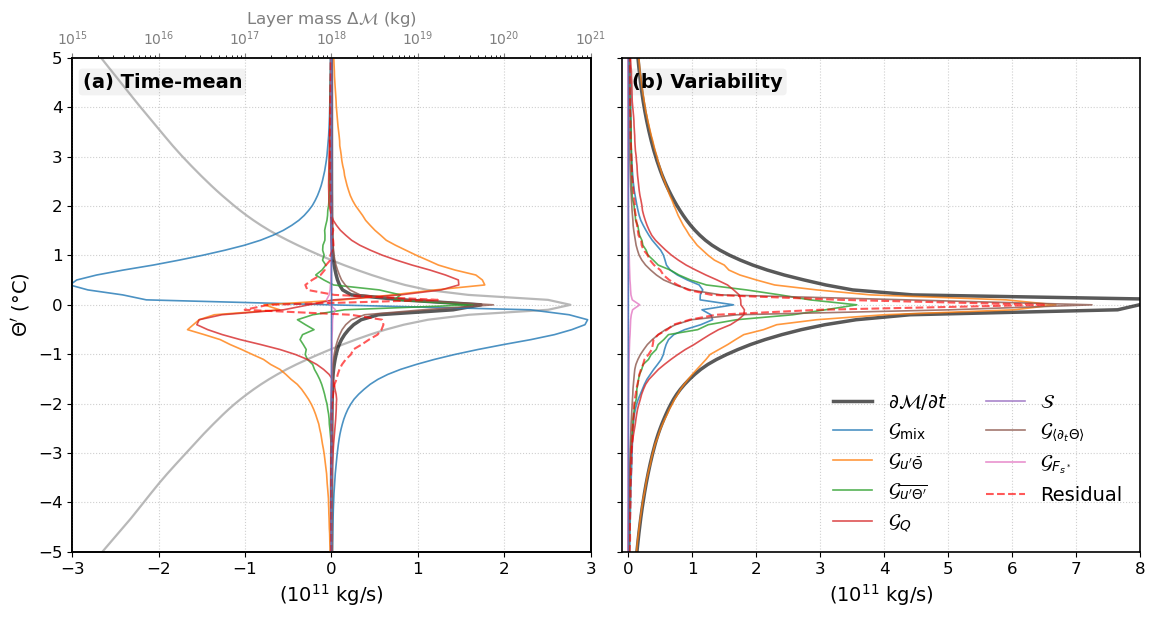

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


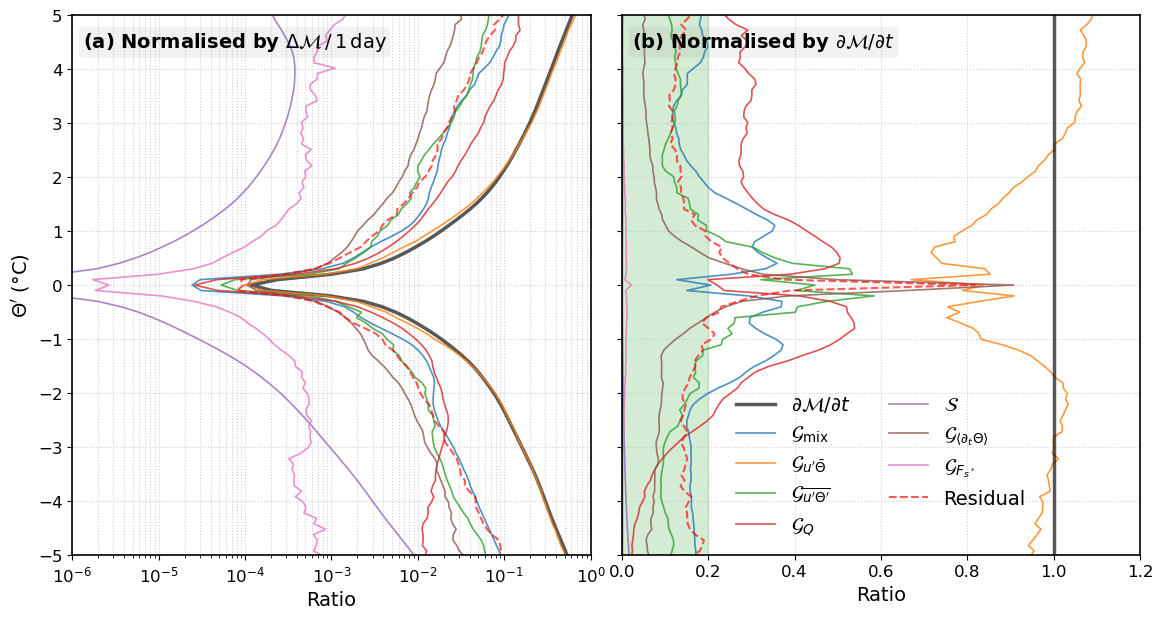

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# =================================================================
# 原 Fig. 6（2×2）拆成两张 1×2：
#   Fig. 6 : (a) Time-mean + ΔM(顶轴)            (b) Variability
#   Fig. 7 : (a) Variability normalised by ΔM    (b) Variability normalised by ∂M/∂t
#            （原来的 (c)(d)）
# =================================================================
DT_REF     = 86400.                     # Δt = 1 day，用来无量纲化
main_terms = ["g_tend", "residual"]
other_terms = [v for v in full_rhs_base_vars if v not in main_terms]

# ---- layer mass：Fig.6(a) 顶轴 和 Fig.7(a) 共用 ----
#      Mass 是累积量 M(Θ′ > tcenter)，中心差分 [M(i-1) - M(i+1)]/2 → 每层质量 ΔM
mass_cum   = full_mean_ds["Mass"]
mass_layer = (mass_cum.shift(tcenter=1) - mass_cum.shift(tcenter=-1)) / 2
mass_layer = mass_layer.where(mass_layer > 0)                # 避免除以 0 / 负值


def plot_terms(ax, data, with_gtend=True):
    """画一组收支项：g_tend 黑粗线 + 其他项细线 + residual 红虚线（各图配色一致）"""
    if with_gtend:
        ax.plot(data["g_tend"], data["tcenter"], linewidth=2.5, color="k", alpha=0.65,
                label=full_label_dict["g_tend"])
    else:
        # 不画 g_tend 时，用一根不可见的线占掉 g_tend 的位置，
        # 保证其他项的默认配色序列与有 g_tend 的面板完全一致
        ax.plot([], [], color="k")
    for var in other_terms:
        ax.plot(data[var], data["tcenter"], linewidth=1.2, alpha=0.8,
                label=full_label_dict.get(var, var))
    ax.plot(data["residual"], data["tcenter"], linewidth=1.5, linestyle="--",
            color="red", alpha=0.65, label=full_label_dict["residual"])


def panel_label(ax, text):
    ax.text(0.02, 0.94, text, transform=ax.transAxes, fontsize=14, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))


def finish_yaxis(axes):
    for ax in axes:
        ax.set_ylim(-5., 5.)
        ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
    axes[0].set_ylabel(r"$\Theta'$ (°C)")


# =================================================================
# Fig. 6：时间平均 + 变率（干净的两幅）
# =================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 6.5), sharey=True)

for data, ax, txt in [(full_mean_ds / 1e11, axes[0], "(a) Time-mean"),
                      (full_std_ds  / 1e11, axes[1], "(b) Variability")]:
    plot_terms(ax, data)
    ax.axvline(0, linewidth=1, alpha=0.6)
    ax.grid(True, linestyle=":", alpha=0.6)
    panel_label(ax, txt)

# ---- (a) 顶部 x 轴叠加 layer mass ΔM（跨 ~5 个量级 → 对数）----
ax     = axes[0]
ax_top = ax.twiny()
ax_top.plot(mass_layer, mass_layer["tcenter"],
            color="tab:grey", linewidth=1.6, alpha=0.55, zorder=0)
ax_top.set_xscale("log")
ax_top.set_xlim(1e15, 1e21)
ax_top.set_xlabel(r"Layer mass $\Delta \mathcal{M}$ (kg)", color="tab:grey", fontsize=12)
ax_top.tick_params(axis="x", colors="tab:grey", labelsize=10)
ax_top.spines["top"].set_color("tab:grey")
ax_top.grid(False)
# twin 轴压到原轴之下 + 原轴背景透明 → 灰线在收支线条下面
ax_top.set_zorder(ax.get_zorder() - 1)
ax.patch.set_visible(False)

axes[0].set_xlim(-3., 3.)
axes[1].set_xlim(-0.1, 8.)
for ax in axes:
    ax.set_xlabel(r"$(10^{11}$ kg/s$)$")
finish_yaxis(axes)

handles, labels = axes[0].get_legend_handles_labels()
axes[1].legend(handles, labels, loc='lower right', ncol=2, frameon=False)

fig.subplots_adjust(left=0.08, right=0.97, top=0.88, bottom=0.12, wspace=0.06)
fig.savefig("Fig6_ecco_budget_mean_std.png", dpi=600, bbox_inches="tight")
fig.savefig("Fig6_ecco_budget_mean_std.pdf", dpi=600, bbox_inches="tight")
plt.show()


# =================================================================
# Fig. 7：变率的两种归一化（原 (c)(d)）
# =================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 6.5), sharey=True)

# ---- (a) 除以 ΔM 再乘 1 day：一天内周转掉的该层质量比例（无量纲）----
ax = axes[0]
per_mass = full_std_ds / mass_layer * DT_REF
plot_terms(ax, per_mass)
ax.set_xscale("log")                    # 跨 ~4 个量级
ax.set_xlim(1e-6, 1e0)
ax.grid(True, linestyle=":", alpha=0.6, which="both")
ax.set_xlabel("Ratio")
panel_label(ax, r"(a) Normalised by $\Delta \mathcal{M}\,/\,1\,\mathrm{day}$")

# ---- (b) 除以 ∂M/∂t 的变率（无量纲；∂M/∂t 自身 ≡ 1）----
ax = axes[1]
denom = full_std_ds["g_tend"].where(full_std_ds["g_tend"] > 0)
ratio = full_std_ds / denom
plot_terms(ax, ratio, with_gtend=False)
ax.axvline(1, linewidth=2.5, color="k", alpha=0.65)                # ∂M/∂t 自身 = 1
ax.axvline(0, linewidth=1, alpha=0.6)
ax.axvspan(0, 0.2, color="tab:green", alpha=0.2)
ax.set_xlim(0., 1.2)
ax.grid(True, linestyle=":", alpha=0.6)
ax.set_xlabel("Ratio")
panel_label(ax, r"(b) Normalised by $\partial \mathcal{M}/\partial t$")

finish_yaxis(axes)

handles, labels = axes[0].get_legend_handles_labels()
axes[1].legend(handles, labels, loc='lower center', ncol=2, frameon=False)

fig.subplots_adjust(left=0.08, right=0.97, top=0.95, bottom=0.12, wspace=0.06)
fig.savefig("Fig7_ecco_budget_std_normalised.png", dpi=1000, bbox_inches="tight")
fig.savefig("Fig7_ecco_budget_std_normalised.pdf", dpi=1000, bbox_inches="tight")
plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


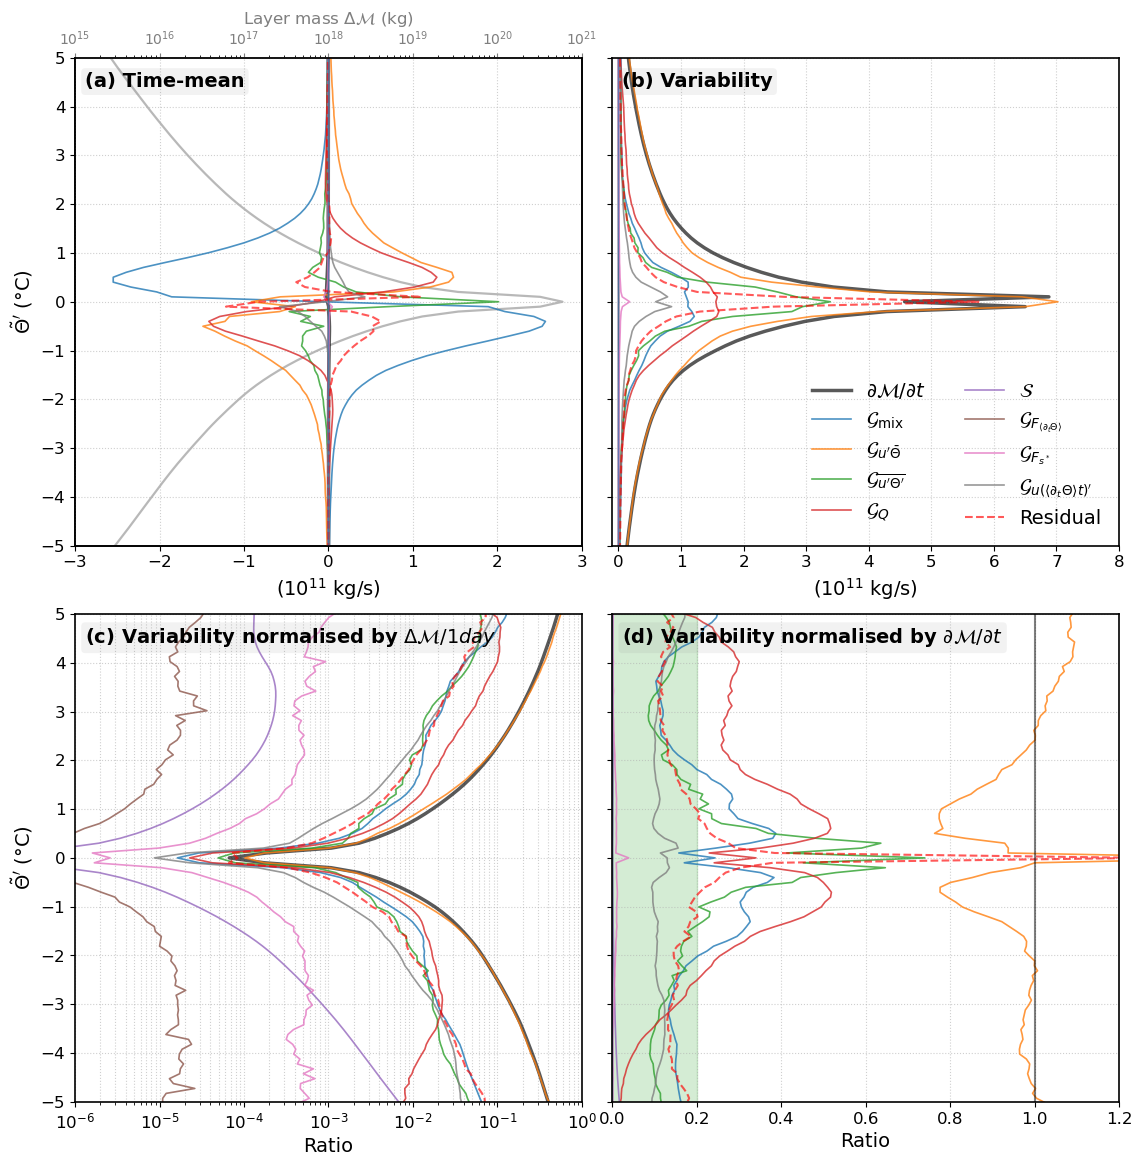

In [16]:
# ------------------------------
# Θ̃′ 版本 2×2（(a) 顶部叠加 layer mass）：
#   (a) Time-mean + ΔM(顶轴)             (b) Variability
#   (c) Variability normalised by ΔM     (d) Variability normalised by ∂M/∂t
# ------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharey=True)

DT_REF = 86400.   # Δt = 1 day，用来无量纲化

# ---- layer mass 提到最前面算，(a) 和 (c) 共用 ----
#      数据里的 Mass 是累积量 M(Θ̃′ > tcenter)，中心差分 [M(i-1) - M(i+1)]/2 → 每层质量 ΔM
mass_cum   = detrend_mean_ds["Mass"]
mass_layer = (mass_cum.shift(tcenter=1) - mass_cum.shift(tcenter=-1)) / 2
mass_layer = mass_layer.where(mass_layer > 0)                # 避免除以 0 / 负值

data_list = [
    (detrend_mean_ds/1e11, axes[0,0], detrend_rhs_base_vars, detrend_label_dict, "(a) Time-mean"),
    (detrend_std_ds/1e11,  axes[0,1], detrend_rhs_base_vars, detrend_label_dict, "(b) Variability"),
]

main_terms = ["g_tend", "residual"]

for data, ax, rhs_vars, label_dict, label_text in data_list:
    # g_tend (黑色粗线)
    ax.plot(data["g_tend"],
            data["tcenter"],
            linewidth=2.5,
            color="k",
            alpha=0.65,
            label=label_dict["g_tend"])

    # 其他项（细线 + alpha=0.8）
    other_terms = [v for v in rhs_vars if v not in main_terms]
    for var in other_terms:
        ax.plot(data[var],
                data["tcenter"],
                linewidth=1.2,
                alpha=0.8,
                label=label_dict.get(var, var))

    # residual（红色虚线）
    ax.plot(data["residual"],
            data["tcenter"],
            linewidth=1.5,
            linestyle="--",
            color="red",
            alpha=0.65,
            label=label_dict["residual"])

    # 美化
    ax.axvline(0, linewidth=1, alpha=0.6)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.set_ylim(-5., 5.)

    # 左上角添加 (a)/(b) 标注
    ax.text(0.02, 0.94, label_text, transform=ax.transAxes,
            fontsize=14, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))

# -----------------------------
# (a) 顶部 x 轴叠加 layer mass ΔM
#     ΔM 从 ±5°C 的 ~3e15 kg 一直到 Θ̃′≈0 的 ~6e20 kg，跨 5 个量级 → 顶轴用对数
#     灰色细线 + 放到收支线条下面，尽量不遮挡
# -----------------------------
ax     = axes[0,0]
ax_top = ax.twiny()

ax_top.plot(mass_layer, mass_layer["tcenter"],
            color="tab:grey", linewidth=1.6, alpha=0.55, zorder=0)

ax_top.set_xscale("log")
ax_top.set_xlim(1e15, 1e21)
ax_top.set_xlabel(r"Layer mass $\Delta \mathcal{M}$ (kg)", color="tab:grey", fontsize=12)
ax_top.tick_params(axis="x", colors="tab:grey", labelsize=10)
ax_top.spines["top"].set_color("tab:grey")
ax_top.grid(False)

# 关键：把 twin 轴压到原轴之下，并让原轴背景透明，
# 这样灰色的 ΔM 曲线在收支线条的下面，不会盖住它们
ax_top.set_zorder(ax.get_zorder() - 1)
ax.patch.set_visible(False)

# -----------------------------
# (c) 单位水团质量（无量纲）
#     σ/ΔM 的量纲是 1/s，再乘上参考时间尺度 Δt = 1 day = 86400 s，
#     得到无量纲数：一天之内周转掉的该层质量的比例。
# -----------------------------
ax = axes[1,0]

per_mass = detrend_std_ds / mass_layer * DT_REF                             # 无量纲

# g_tend (黑色粗线)
ax.plot(per_mass["g_tend"], per_mass["tcenter"],
        linewidth=2.5, color="k", alpha=0.65,
        label=detrend_label_dict["g_tend"])

# 其他项（细线 + alpha=0.8），顺序与 (b) 相同 → 配色自动对应
for var in [v for v in detrend_rhs_base_vars if v not in main_terms]:
    ax.plot(per_mass[var], per_mass["tcenter"],
            linewidth=1.2, alpha=0.8,
            label=detrend_label_dict.get(var, var))

# residual（红色虚线）
ax.plot(per_mass["residual"], per_mass["tcenter"],
        linewidth=1.5, linestyle="--", color="red", alpha=0.65,
        label=detrend_label_dict["residual"])

ax.set_xscale("log")          # 跨 ~4 个量级，必须用对数轴
ax.grid(True, linestyle=":", alpha=0.6, which="both")
ax.set_ylim(-5., 5.)
#ax.legend(loc='lower left', frameon=False)
ax.text(0.02, 0.94, r"(c) Variability normalised by $\Delta \mathcal{M} / 1day $",
        transform=ax.transAxes,
        fontsize=14, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))

# -----------------------------
# (d) 把 (b) 的各项除以 ∂M/∂t 这一项做归一化（无量纲）
# -----------------------------
ax = axes[1,1]

denom = detrend_std_ds["g_tend"].where(detrend_std_ds["g_tend"] > 0)   # 避免除以 0
ratio = detrend_std_ds / denom                                          # 量纲/系数都被约掉

other_terms = [v for v in detrend_rhs_base_vars if v not in main_terms]
for var in other_terms:
    ax.plot(ratio[var], ratio["tcenter"],
            linewidth=1.2, alpha=0.8, label=detrend_label_dict.get(var, var))

ax.plot(ratio["residual"], ratio["tcenter"],
        linewidth=1.5, linestyle="--", color="red", alpha=0.65,
        label=detrend_label_dict["residual"])

ax.axvline(1, linewidth=1.5, color="k", alpha=0.5, linestyle="-")  # 自身 = 1
ax.axvline(0, linewidth=1, alpha=0.6)
ax.axvspan(0, 0.2, color="tab:green", alpha=0.2)

ax.grid(True, linestyle=":", alpha=0.6)
ax.set_ylim(-5., 5.)
ax.text(0.02, 0.94, r"(d) Variability normalised by $\partial \mathcal{M}/\partial t$",
        transform=ax.transAxes,
        fontsize=14, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))

# -----------------------------
# x/y label 与坐标范围
# -----------------------------
axes[0,0].set_xlim(-3., 3.)
axes[0,1].set_xlim(-0.1, 8.)
axes[1,0].set_xlim(1e-6, 1e0)
axes[1,1].set_xlim(0., 1.2)

axes[0,0].set_xlabel(r"$(10^{11}$ kg/s$)$")
axes[0,1].set_xlabel(r"$(10^{11}$ kg/s$)$")
#axes[1,0].set_xlabel(r"Ratio  ($\times\,1\,$day$\,/\,\Delta \mathcal{M}$)")
axes[1,0].set_xlabel(r"Ratio")
axes[1,1].set_xlabel(r"Ratio")

axes[0,0].set_ylabel(r"$\tilde{\Theta}'$ (°C)")
axes[1,0].set_ylabel(r"$\tilde{\Theta}'$ (°C)")

# y 轴刻度：每 1 °C 一个（sharey，所以设一个就够，这里全设一遍更保险）
for ax in axes.flat:
    ax.yaxis.set_major_locator(mticker.MultipleLocator(1))

# legend 统一
handles, labels = axes[0,0].get_legend_handles_labels()
axes[0,1].legend(handles, labels, loc='lower right', ncol=2, frameon=False)

# hspace 加大：上排现在有 xlabel，太挤会压到下排面板上
fig.subplots_adjust(left=0.08, right=0.95, top=0.95, bottom=0.08,
                    wspace=0.06, hspace=0.14)

# 保存
fig.savefig("Fig_ecco_detrendprime_STD_2x2_norm_layermass.png", dpi=1000, bbox_inches="tight")
fig.savefig("Fig_ecco_detrendprime_STD_2x2_norm_layermass.pdf", dpi=1000, bbox_inches="tight")

plt.show()


# old

# full anomaly

In [2]:

# ==========================================
# 1. 数据构造与合并 (基于你的变量名)
# ==========================================
# 假设 ds 是你加载的原始 xarray Dataset
combined = xr.Dataset({
    "g_tend": ds["g_tend"],
    "g_mix_total": ds["g_mix_h"] + ds["g_mix_v"],
    "g_UpTb_total": ds["g_UpTb_h"] + ds["g_UpTb_v"],
    "g_UpTp_total": ds["g_UpTp_h"] + ds["g_UpTp_v"],
    "g_heat": ds["g_heat"],
    "g_fw": ds["g_fw"],
    "g_trend":ds["g_trend"],
    "g_Fsstar":ds["g_Fsstar"],
})

# 定义基础的 RHS 项（不含 g_trend）
rhs_base_vars = ["g_mix_total", "g_UpTb_total", "g_UpTp_total", "g_heat", "g_fw","g_Fsstar"]

# 计算不含 g_trend 的残差
combined["res_no_trend"] = (
    combined["g_tend"] - sum(combined[v] for v in rhs_base_vars)
)

# 计算包含 g_trend 的残差
combined["res_with_trend"] = (
    combined["g_tend"] - (sum(combined[v] for v in rhs_base_vars) + combined["g_trend"])
)
# ==========================================
# 2. 统计与绘图
# ==========================================
mean_ds = combined.mean(dim="time")
std_ds = combined.std(dim="time")


In [5]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl

# ---- JPO 风格 ----
mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.2,
})

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


combined = xr.Dataset({
    "g_tend": ds["g_tend"],
    "g_mix_total": ds["g_mix_h"] + ds["g_mix_v"],
    "g_UpTb_total": ds["g_UpTb_h"] + ds["g_UpTb_v"],
    "g_UpTp_total": ds["g_UpTp_h"] + ds["g_UpTp_v"],
    "g_heat": ds["g_heat"],
    "g_fw": ds["g_fw"],
    "g_trend": ds["g_trend"],
    "g_Fsstar": ds["g_Fsstar"],
})

rhs_base_vars = [
    "g_mix_total",
    "g_UpTb_total",
    "g_UpTp_total",
    "g_heat",
    "g_fw",
    "g_trend",
    "g_Fsstar"
]

#combined["res_no_trend"] = (
#    combined["g_tend"] - sum(combined[v] for v in rhs_base_vars)
#)

combined["residual"] = (
    combined["g_tend"]
    - (sum(combined[v] for v in rhs_base_vars) )
)

window = 30

combined_smooth = combined.rolling(
    time=window,
    center=True,
).mean()

mean_ds = combined_smooth.mean(dim="time")
std_ds  = combined_smooth.std(dim="time")

label_dict = {
    "g_tend": r"$\partial \mathcal{M}/\partial t$",
    "g_mix_total": r"$\mathcal{G}_{\mathrm{mix}}$",
    "g_UpTb_total": r"$\mathcal{G}_{u'\bar{\Theta}}$",
    "g_UpTp_total": r"$\mathcal{G}_{\overline{u'\Theta'}}$",
    "g_heat": r"$\mathcal{G}_{Q}$",
    "g_fw": r"$\mathcal{G}_{FW}$",
    "g_trend": r"$\mathcal{G}_{\mathrm{trend}}$",
    "g_Fsstar": r"$\mathcal{G}_{F_{s^*}}$",
    "residual": "Residual",
}


In [ ]:
# ==========================================
# Mean & Std Plot (风格统一版)
# ==========================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

main_terms = ["g_tend", "residual"]

other_terms = [
    v for v in rhs_base_vars
    if v not in main_terms
]

# ----------------------------------
# 2️⃣ g_tend（黑色粗线）
# ----------------------------------
for ax, data in zip([ax1, ax2], [mean_ds, std_ds]):
    ax.plot(data["g_tend"],
            data["tcenter"],
            linewidth=2.5,
            color="k",
            alpha=0.65,
            label=label_dict["g_tend"])
    
# ----------------------------------
# 1️⃣ 其他项（细线 + alpha=0.8）
# ----------------------------------
for var in other_terms:
    ax1.plot(mean_ds[var],
             mean_ds["tcenter"],
             linewidth=1.2,
             alpha=0.8,
             label=label_dict.get(var, var))

    ax2.plot(std_ds[var],
             std_ds["tcenter"],
             linewidth=1.2,
             alpha=0.8,
             label=label_dict.get(var, var))


# ----------------------------------
# 3️⃣ residual（红色虚线）
# ----------------------------------
for ax, data in zip([ax1, ax2], [mean_ds, std_ds]):
    ax.plot(data["residual"],
            data["tcenter"],
            linewidth=2.0,
            linestyle="--",
            color="red",
            alpha=0.65,
            label=label_dict["residual"])

# ----------------------------------
# 4️⃣ 美化
# ----------------------------------
ax1.set_title("Mean")
ax2.set_title("Standard Deviation")

ax1.set_xlabel("kg s$^{-1}$")
ax2.set_xlabel("kg s$^{-1}$")
ax1.set_ylabel(r"$\Theta'$ (°C)")

ax1.set_ylim(-5.5,5.5)
ax2.set_ylim(-5.5,5.5)

for ax in [ax1, ax2]:
    ax.axvline(0, linewidth=1, alpha=0.6)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ----------------------------------
# 5️⃣ 统一 legend（只取一套）
# ----------------------------------
#handles, labels = ax1.get_legend_handles_labels()
#fig.legend(handles, labels,
#           loc="lower right",
#           frameon=False)

# 获取 legend handles
handles, labels = ax1.get_legend_handles_labels()

# 放入 ax2 内部右下角，横向两行
ax2.legend(
    handles, labels,
    loc='lower right',
    ncol=2,            # 横着排列，2列
    frameon=False
)


fig.tight_layout(rect=[0, 0, 0.85, 1])


fig.savefig("Fig_ecco_thetaprime_STD.png",dpi=1000,bbox_inches="tight")
fig.savefig("Fig_ecco_thetaprime_STD.pdf",dpi=1000,bbox_inches="tight",transparent=True)


plt.show()


In [40]:
rhs_base_vars

['g_mix_total', 'g_UpTb_total', 'g_UpTp_total', 'g_heat', 'g_fw', 'g_Fsstar']

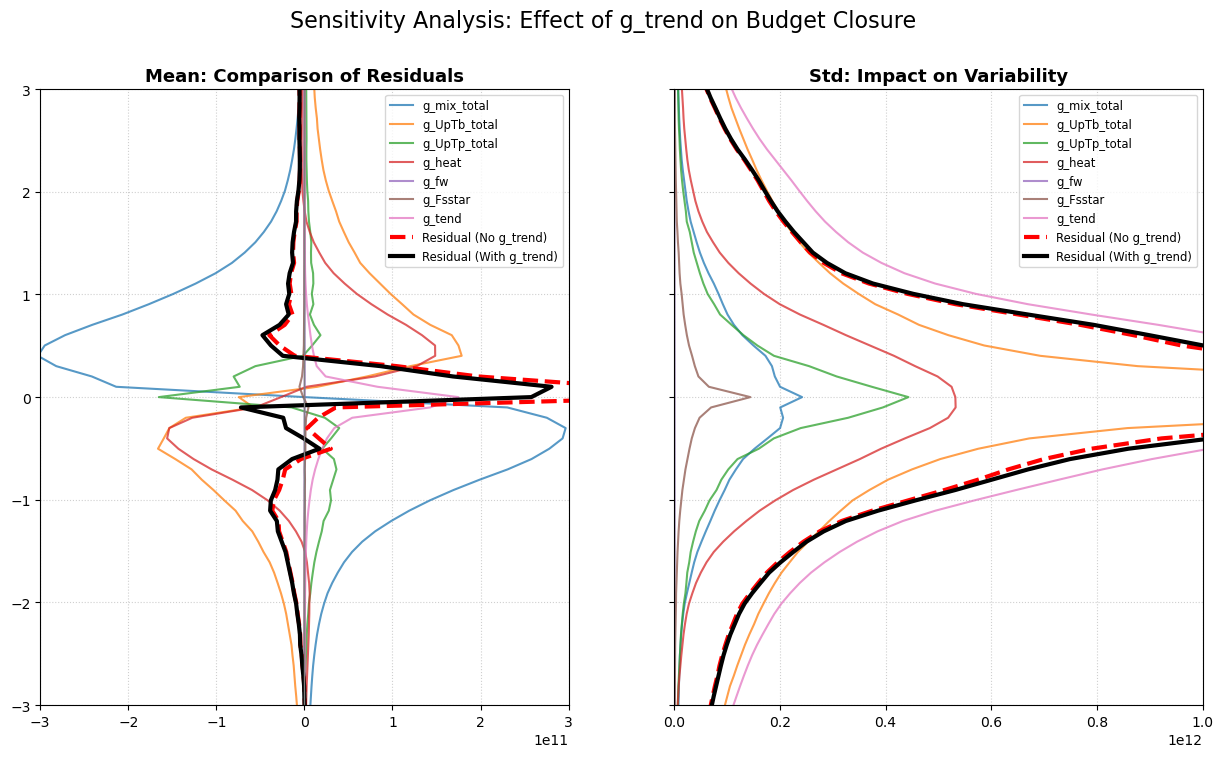

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8), sharey=True)

# 绘制原始预算项 (供参考)
base_colors = plt.cm.tab10(np.linspace(0, 1, len(rhs_base_vars) + 1))
for i, var in enumerate(rhs_base_vars + ["g_tend"]):
    ax1.plot(mean_ds[var], mean_ds['tcenter'], label=var, alpha=0.75, lw=1.5)
    ax2.plot(std_ds[var], std_ds['tcenter'], label=var, alpha=0.75, lw=1.5)

# 核心比较：两种残差的对比
# 使用醒目的颜色和线型
res_configs = [
    ('res_no_trend', 'red', '--', 'Residual (No g_trend)'),
    ('res_with_trend', 'black', '-', 'Residual (With g_trend)')
]

for var, color, ls, lab in res_configs:
    # Mean 图
    ax1.plot(mean_ds[var], mean_ds['tcenter'], 
             label=lab, color=color, linestyle=ls, linewidth=3)
    # Std 图
    ax2.plot(std_ds[var], std_ds['tcenter'], 
             label=lab, color=color, linestyle=ls, linewidth=3)

# ==========================================
# 3. 细节美化
# ==========================================
ax1.set_title('Mean: Comparison of Residuals', fontsize=13, fontweight='bold')
ax2.set_title('Std: Impact on Variability', fontsize=13, fontweight='bold')
ax1.set_xlim(-3e11,3e11)
ax2.set_xlim(0,1e12)

for ax in [ax1, ax2]:
    ax.axvline(0, color='gray', lw=1)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(fontsize='small')

plt.ylim(-3, 3) 
plt.suptitle('Sensitivity Analysis: Effect of g_trend on Budget Closure', fontsize=16)
plt.show()

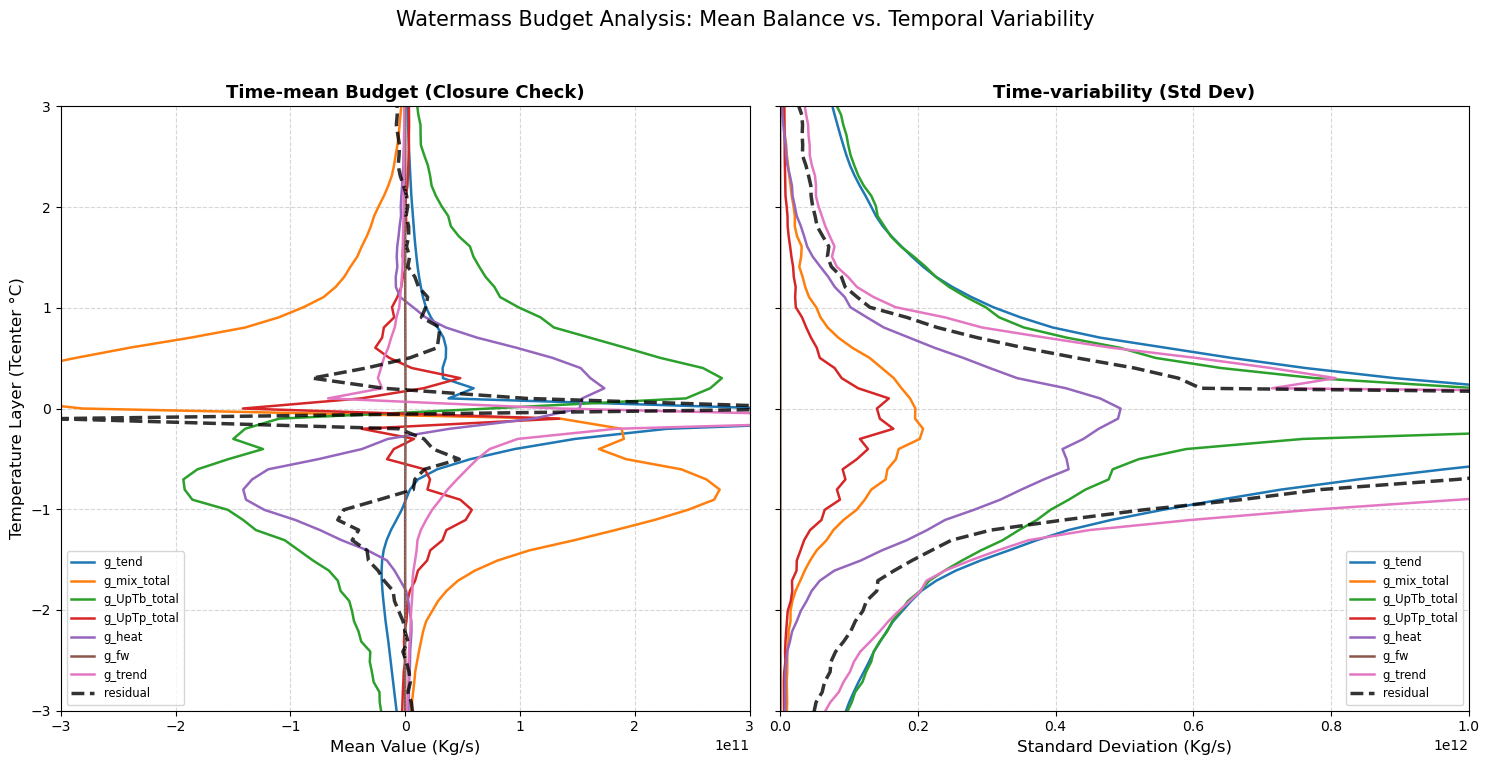

In [8]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np

# ==========================================
# 1. 数据构造与合并 (基于你的变量名)
# ==========================================
# 假设 ds 是你加载的原始 xarray Dataset
combined = xr.Dataset({
    "g_tend": ds["g_tend"],
    "g_mix_total": ds["g_mix_h"] + ds["g_mix_v"],
    "g_UpTb_total": ds["g_UpTb_h"] + ds["g_UpTb_v"],
    "g_UpTp_total": ds["g_UpTp_h"] + ds["g_UpTp_v"],
    "g_heat": ds["g_heat"],
    "g_fw": ds["g_fw"],
    "g_trend":ds["g_trend"]
})

# --- 核心步骤：在统计前计算残差序列 ---
# 这样 residual 会作为一个普通变量存在于 combined 中
# 随后的 .mean() 和 .std() 会自动包含它
combined["residual"] = (
    combined["g_tend"] 
    - sum(combined[v] for v in combined.data_vars if v != "g_tend")
)

# ==========================================
# 2. 统计量计算 (沿时间维度)
# ==========================================
mean_ds = combined.mean(dim="time")
std_ds = combined.std(dim="time")

# ==========================================
# 3. 绘图：左图 Mean，右图 Std
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8), sharey=True)

# 定义要画的变量列表
# 我们把 residual 挑出来最后画，或者给它特殊样式
plot_vars = [v for v in mean_ds.data_vars if v != 'residual'] + ['residual']

for var in plot_vars:
    # 样式配置：如果是残差，使用黑色虚线；否则使用普通实线
    is_res = (var == 'residual')
    ls = '--' if is_res else '-'
    color = 'black' if is_res else None
    alpha = 0.8 if is_res else 1.0
    lw = 2.5 if is_res else 1.8

    # --- 左子图：时间平均剖面 ---
    ax1.plot(mean_ds[var], mean_ds['tcenter'], 
             label=var, linestyle=ls, color=color, alpha=alpha, linewidth=lw)
    
    # --- 右子图：时间标准差剖面 ---
    ax2.plot(std_ds[var], std_ds['tcenter'], 
             label=var, linestyle=ls, color=color, alpha=alpha, linewidth=lw)

# ==========================================
# 4. 图表细节美化
# ==========================================

# 左图配置 (Mean)
ax1.axvline(0, color='gray', linestyle=':', linewidth=1)
ax1.set_xlabel('Mean Value (Kg/s)', fontsize=12)
ax1.set_ylabel('Temperature Layer (Tcenter °C)', fontsize=12)
ax1.set_title('Time-mean Budget (Closure Check)', fontsize=13, fontweight='bold')
ax1.set_xlim(-3e11, 3e11) # 根据你的数据量级微调
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='lower left', fontsize='small', frameon=True)

# 右图配置 (Standard Deviation)
ax2.axvline(0, color='gray', linestyle=':', linewidth=1)
ax2.set_xlabel('Standard Deviation (Kg/s)', fontsize=12)
ax2.set_title('Time-variability (Std Dev)', fontsize=13, fontweight='bold')
ax2.set_xlim(0, 1e12) # Std 通常比 Mean 大，动态调整范围
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='lower right', fontsize='small', frameon=True)

# 统一 Y 轴 (温度层)
plt.ylim(-3, 3) 

# 总标题
plt.suptitle('Watermass Budget Analysis: Mean Balance vs. Temporal Variability', 
             fontsize=15, y=0.98)



plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

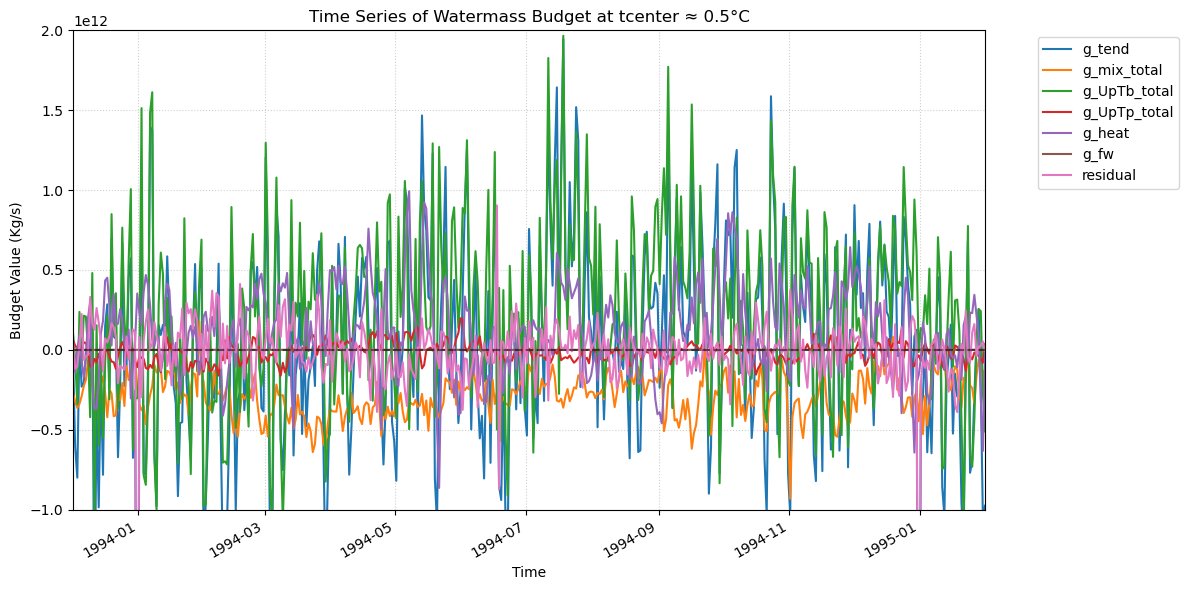

In [5]:
import matplotlib.pyplot as plt
import xarray as xr

# --- 1. 选择特定的温度层 ---
# 假设你想看 0°C 层，或者你可以根据实际坐标选择，例如 tcenter=1.5
target_temp = 0.5 
ts_layer = combined.sel(tcenter=target_temp, method="nearest")

# --- 2. 计算该层的残差序列 ---
ts_layer["residual"] = (
    ts_layer["g_tend"]
    - sum(ts_layer[v] for v in ts_layer.data_vars if v not in ["g_tend", "residual"])
)

# --- 3. 绘图 ---
plt.figure(figsize=(12, 6))

for var in ts_layer.data_vars:
    # 针对每一项绘图
    plt.plot(ts_layer.time, ts_layer[var], label=var, linewidth=1.5)

plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Time')
plt.xlim(ts_layer.time[0],ts_layer.time[-1])

plt.ylabel('Budget Value (Kg/s)')
plt.ylim(-1e12,2e12)

plt.title(f'Time Series of Watermass Budget at tcenter ≈ {target_temp}°C')

# 自动格式化时间轴
plt.gcf().autofmt_xdate()

# 图例放在右侧
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [10]:
import matplotlib.pyplot as plt
import xarray as xr

# --- 1. 选择特定的温度层 ---
target_temp = 3.5 
ts_layer = combined.sel(tcenter=target_temp, method="nearest")


# --- 2. 平滑处理 (30天滑动平均) ---
# center=True 保证平滑后的趋势在时间轴上是对齐的
window_size = 30  # 你可以改成 90 (季) 或 365 (年)
ts_layer_smooth = ts_layer.rolling(time=window_size, center=True).mean()

label_dict = {
    "g_tend": r"$\partial \mathcal{M}/\partial t$",
    "g_mix_total": r"$\mathcal{G}_{\mathrm{mix}}$",
    "g_UpTb_total": r"$\mathcal{G}_{u'\bar{\Theta}}$",
    "g_UpTp_total": r"$\mathcal{G}_{\overline{u'\Theta'}}$",
    "g_heat": r"$\mathcal{G}_{Q}$",
    "g_fw": r"$\mathcal{G}_{FW}$",
    "g_trend": r"$\mathcal{G}_{\mathrm{trend}}$",
    "g_Fsstar": r"$\mathcal{G}_{F_{s^*}}$",
    "residual": "Residual",
}

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# ------------------------------
# 1. 全局风格设置（期刊风格）
# ------------------------------
mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.2,
})

# ------------------------------
# 2. 变量分组
# ------------------------------
main_terms = ["g_tend", "residual"]
exclude = ["res_no_trend"]

other_terms = [
    v for v in ts_layer_smooth.data_vars
    if v not in main_terms and v not in exclude
]

# ------------------------------
# 3. 画图
# ------------------------------
fig, ax = plt.subplots(figsize=(12, 4))


# (b) 主平衡项：强调
ax.plot(ts_layer_smooth.time,
        ts_layer_smooth["g_tend"],
        linewidth=2.5,
        color="k",
        alpha=0.65,
        label=r"$\partial M/\partial t$")

# (a) 次要项：细线 + 半透明
for var in other_terms:
    ax.plot(ts_layer_smooth.time,
            ts_layer_smooth[var],
            linewidth=1.2,
            alpha=0.8,
            label=label_dict.get(var, var) )


ax.plot(ts_layer_smooth.time,
        ts_layer_smooth["residual"],
        linewidth=2.,
        linestyle="--",
        color="red",
        alpha=0.65,
        label="Residual")

# 0 线
ax.axhline(0, linestyle='--', linewidth=1, alpha=0.6)

# 坐标轴
ax.set_xlim(ts_layer_smooth.time[0], ts_layer_smooth.time[-1])
ax.set_ylabel("Water-mass transformation (kg s$^{-1}$)")
ax.set_ylim(-2e11, 2e11)

#ax.set_title(f"{window_size}-day Smoothed Budget at \Theta^{\prime} > {target_temp}°C")
ax.set_title(
    rf"{window_size}-day Smoothed Budget at "
    rf"$\Theta^\prime > {target_temp}^\circ$C"
)

# 去掉上右边框（期刊常见风格）
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# legend 放图外
ax.legend(frameon=False,ncol=5, bbox_to_anchor=(0.35, 0.25), loc='upper left')


fig.autofmt_xdate()
fig.tight_layout()


fig.savefig("Fig_ecco_thetaprime_Alltimeseries.png",dpi=1000,bbox_inches="tight")
fig.savefig("Fig_ecco_thetaprime_Alltimeseries.pdf",dpi=1000,bbox_inches="tight",transparent=True)

plt.show()


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


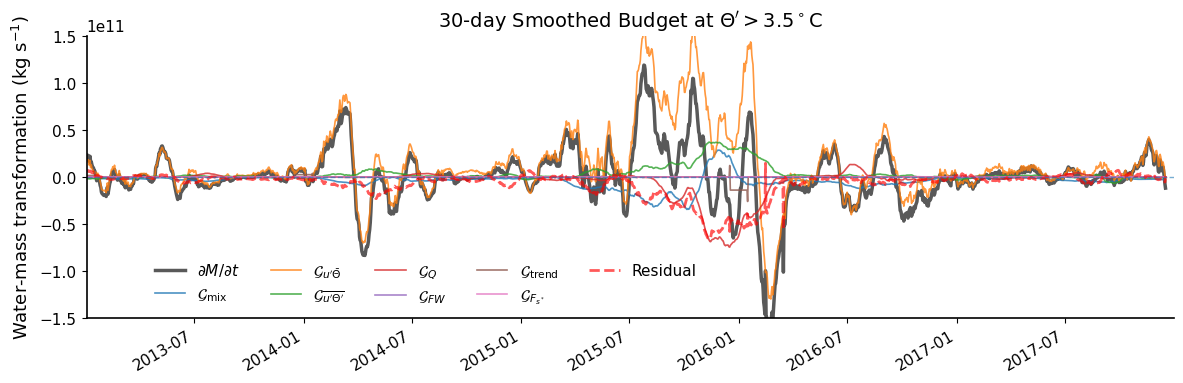

In [47]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# ------------------------------
# 1. 全局风格设置（期刊风格）
# ------------------------------
mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.2,
})

# ------------------------------
# 2. 变量分组
# ------------------------------
main_terms = ["g_tend", "residual"]
exclude = ["res_no_trend"]

other_terms = [
    v for v in ts_layer_smooth.data_vars
    if v not in main_terms and v not in exclude
]

# ------------------------------
# 3. 画图
# ------------------------------
fig, ax = plt.subplots(figsize=(12, 4))


# (b) 主平衡项：强调
ax.plot(ts_layer_smooth.time,
        ts_layer_smooth["g_tend"],
        linewidth=2.5,
        color="k",
        alpha=0.65,
        label=r"$\partial M/\partial t$")

# (a) 次要项：细线 + 半透明
for var in other_terms:
    ax.plot(ts_layer_smooth.time,
            ts_layer_smooth[var],
            linewidth=1.2,
            alpha=0.8,
            label=label_dict.get(var, var) )


ax.plot(ts_layer_smooth.time,
        ts_layer_smooth["residual"],
        linewidth=2.,
        linestyle="--",
        color="red",
        alpha=0.65,
        label="Residual")

# 0 线
ax.axhline(0, linestyle='--', linewidth=1, alpha=0.6)

# 坐标轴
ax.set_xlim(ts_layer_smooth.time[0], ts_layer_smooth.time[-1])
ax.set_ylabel("Water-mass transformation (kg s$^{-1}$)")
ax.set_ylim(-1.5e11, 1.5e11)
ax.set_xlim(ts_layer_smooth.time[-1825],ts_layer_smooth.time[-1])

#ax.set_title(f"{window_size}-day Smoothed Budget at \Theta^{\prime} > {target_temp}°C")
ax.set_title(
    rf"{window_size}-day Smoothed Budget at "
    rf"$\Theta^\prime > {target_temp}^\circ$C"
)

# 去掉上右边框（期刊常见风格）
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# legend 放图外
ax.legend(frameon=False,ncol=5, bbox_to_anchor=(0.05, 0.25), loc='upper left')


fig.autofmt_xdate()
fig.tight_layout()


fig.savefig("Fig_ecco_thetaprime_ZoomIntimeseries.png",dpi=1000,bbox_inches="tight")
fig.savefig("Fig_ecco_thetaprime_ZoomIntimeseries.pdf",dpi=1000,bbox_inches="tight",transparent=True)

plt.show()


# detrend anomaly

In [3]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl

ds = detrend_ds

# ---- JPO 风格 ----
mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.2,
})

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


combined = xr.Dataset({
    "g_tend": ds["g_tend"],
    "g_mix_total": ds["g_mix_h"] + ds["g_mix_v"],
    "g_UpTb_total": ds["g_UpTb_h"] + ds["g_UpTb_v"],
    "g_UpTp_total": ds["g_UpTp_h"] + ds["g_UpTp_v"],
    "g_heat": ds["g_heat"],
    "g_fw": ds["g_fw"],
    "g_trend": ds["g_trend"],
    "g_Fsstar": ds["g_Fsstar"],
    "g_Fsatp":ds["g_Fsatp"],
    "g_uatp":ds["g_uatp_h"]+ ds["g_uatp_v"],    
})

rhs_base_vars = [
    "g_mix_total",
    "g_UpTb_total",
    "g_UpTp_total",
    "g_heat",
    "g_fw",
    "g_trend",
    "g_Fsstar",
    "g_Fsatp",
    "g_uatp",
]

#combined["res_no_trend"] = (
#    combined["g_tend"] - sum(combined[v] for v in rhs_base_vars)
#)

combined["residual"] = (
    combined["g_tend"]
    - (sum(combined[v] for v in rhs_base_vars) )
)

window = 30

combined_smooth = combined.rolling(
    time=window,
    center=True,
).mean()

mean_ds = combined_smooth.mean(dim="time")
std_ds  = combined_smooth.std(dim="time")

label_dict = {
    "g_tend": r"$\partial \mathcal{M}/\partial t$",
    "g_mix_total": r"$\mathcal{G}_{\mathrm{mix}}$",
    "g_UpTb_total": r"$\mathcal{G}_{u'\bar{\Theta}}$",
    "g_UpTp_total": r"$\mathcal{G}_{\overline{u'\Theta'}}$",
    "g_heat": r"$\mathcal{G}_{Q}$",
    "g_fw": r"$\mathcal{G}_{FW}$",
    "g_trend": r"$\mathcal{G}_{\mathrm{trend}}$",
    "g_Fsstar": r"$\mathcal{G}_{F_{s^*}}$",
    "g_Fsatp": r"$\mathcal{G}_{F_{s^{*}atp1}}$",
    "g_uatp": r"$\mathcal{G}_{F_{s^{*}atp2}}$",
    "residual": "Residual",
}

In [5]:
import matplotlib.pyplot as plt
import xarray as xr

# --- 1. 选择特定的温度层 ---
target_temp = 3.5 
ts_layer = combined.sel(tcenter=target_temp, method="nearest")


# --- 2. 平滑处理 (30天滑动平均) ---
# center=True 保证平滑后的趋势在时间轴上是对齐的
window_size = 30  # 你可以改成 90 (季) 或 365 (年)
ts_layer_smooth = ts_layer.rolling(time=window_size, center=True).mean()
#ts_layer_smooth = ts_layer

label_dict = {
    "g_tend": r"$\partial \mathcal{M}/\partial t$",
    "g_mix_total": r"$\mathcal{G}_{\mathrm{mix}}$",
    "g_UpTb_total": r"$\mathcal{G}_{u'\bar{\Theta}}$",
    "g_UpTp_total": r"$\mathcal{G}_{\overline{u'\Theta'}}$",
    "g_heat": r"$\mathcal{G}_{Q}$",
    "g_fw": r"$\mathcal{G}_{FW}$",
    "g_trend": r"$\mathcal{G}_{\mathrm{trend}}$",
    "g_Fsstar": r"$\mathcal{G}_{F_{s^*}}$",
    "g_Fsatp": r"$\mathcal{G}_{F_{s^{*}atp1}}$",
    "g_uatp": r"$\mathcal{G}_{F_{s^{*}atp2}}$",
    "residual": "Residual",
}

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# ------------------------------
# 1. 全局风格设置（期刊风格）
# ------------------------------
mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.2,
})

# ------------------------------
# 2. 变量分组
# ------------------------------
main_terms = ["g_tend", "residual"]
exclude = ["res_no_trend"]

other_terms = [
    v for v in ts_layer_smooth.data_vars
    if v not in main_terms and v not in exclude
]

# ------------------------------
# 3. 画图
# ------------------------------
fig, ax = plt.subplots(figsize=(12, 4))


# (b) 主平衡项：强调
ax.plot(ts_layer_smooth.time,
        ts_layer_smooth["g_tend"],
        linewidth=2.5,
        color="k",
        alpha=0.65,
        label=r"$\partial M/\partial t$")

# (a) 次要项：细线 + 半透明
for var in other_terms:
    ax.plot(ts_layer_smooth.time,
            ts_layer_smooth[var],
            linewidth=1.2,
            alpha=0.8,
            label=label_dict.get(var, var) )


ax.plot(ts_layer_smooth.time,
        ts_layer_smooth["residual"],
        linewidth=2.,
        linestyle="--",
        color="red",
        alpha=0.65,
        label="Residual")

# 0 线
ax.axhline(0, linestyle='--', linewidth=1, alpha=0.6)

# 坐标轴
ax.set_xlim(ts_layer_smooth.time[0], ts_layer_smooth.time[-1])
ax.set_ylabel("Water-mass transformation (kg s$^{-1}$)")
ax.set_ylim(-2.5e11, 2.5e11)

#ax.set_title(f"{window_size}-day Smoothed Budget at \Theta^{\prime} > {target_temp}°C")
ax.set_title(
    rf"{window_size}-day Smoothed Budget at "
    rf"$\Theta^\prime > {target_temp}^\circ$C"
)

# 去掉上右边框（期刊常见风格）
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# legend 放图外
ax.legend(frameon=False,ncol=6, bbox_to_anchor=(0.075, 0.3), loc='upper left',fontsize=14)


fig.autofmt_xdate()
fig.tight_layout()


#fig.savefig("Fig_ecco_thetaprime_Alltimeseries.png",dpi=1000,bbox_inches="tight")
#fig.savefig("Fig_ecco_thetaprime_Alltimeseries.pdf",dpi=1000,bbox_inches="tight",transparent=True)

plt.show()

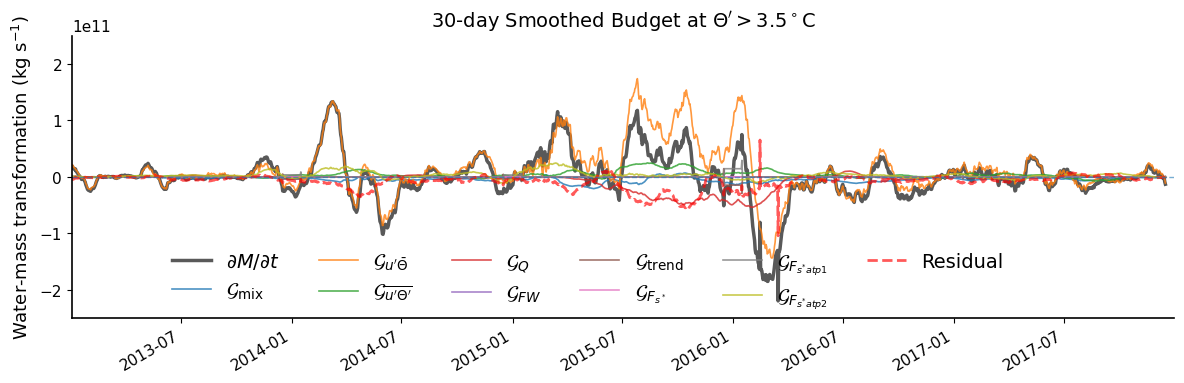

In [14]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# ------------------------------
# 1. 全局风格设置（期刊风格）
# ------------------------------
mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.2,
})

# ------------------------------
# 2. 变量分组
# ------------------------------
main_terms = ["g_tend", "residual"]
exclude = ["res_no_trend"]

other_terms = [
    v for v in ts_layer_smooth.data_vars
    if v not in main_terms and v not in exclude
]

# ------------------------------
# 3. 画图
# ------------------------------
fig, ax = plt.subplots(figsize=(12, 4))


# (b) 主平衡项：强调
ax.plot(ts_layer_smooth.time,
        ts_layer_smooth["g_tend"],
        linewidth=2.5,
        color="k",
        alpha=0.65,
        label=r"$\partial M/\partial t$")

# (a) 次要项：细线 + 半透明
for var in other_terms:
    ax.plot(ts_layer_smooth.time,
            ts_layer_smooth[var],
            linewidth=1.2,
            alpha=0.8,
            label=label_dict.get(var, var) )


ax.plot(ts_layer_smooth.time,
        ts_layer_smooth["residual"],
        linewidth=2.,
        linestyle="--",
        color="red",
        alpha=0.65,
        label="Residual")

# 0 线
ax.axhline(0, linestyle='--', linewidth=1, alpha=0.6)

# 坐标轴
ax.set_xlim(ts_layer_smooth.time[0], ts_layer_smooth.time[-1])
ax.set_ylabel("Water-mass transformation (kg s$^{-1}$)")
ax.set_ylim(-2.5e11, 2.5e11)
ax.set_xlim(ts_layer_smooth.time[-1825],ts_layer_smooth.time[-1])

#ax.set_title(f"{window_size}-day Smoothed Budget at \Theta^{\prime} > {target_temp}°C")
ax.set_title(
    rf"{window_size}-day Smoothed Budget at "
    rf"$\Theta^\prime > {target_temp}^\circ$C"
)

# 去掉上右边框（期刊常见风格）
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# legend 放图外
ax.legend(frameon=False,ncol=6, bbox_to_anchor=(0.075, 0.3), loc='upper left',fontsize=14)


fig.autofmt_xdate()
fig.tight_layout()


#fig.savefig("Fig_ecco_thetaprime_Alltimeseries.png",dpi=1000,bbox_inches="tight")
#fig.savefig("Fig_ecco_thetaprime_Alltimeseries.pdf",dpi=1000,bbox_inches="tight",transparent=True)

plt.show()

In [ ]:
# ==========================================
# Mean & Std Plot (风格统一版)
# ==========================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

main_terms = ["g_tend", "residual"]

other_terms = [
    v for v in rhs_base_vars
    if v not in main_terms
]

# ----------------------------------
# 2️⃣ g_tend（黑色粗线）
# ----------------------------------
for ax, data in zip([ax1, ax2], [mean_ds, std_ds]):
    ax.plot(data["g_tend"],
            data["tcenter"],
            linewidth=2.5,
            color="k",
            alpha=0.65,
            label=label_dict["g_tend"])
    
# ----------------------------------
# 1️⃣ 其他项（细线 + alpha=0.8）
# ----------------------------------
for var in other_terms:
    ax1.plot(mean_ds[var],
             mean_ds["tcenter"],
             linewidth=1.2,
             alpha=0.8,
             label=label_dict.get(var, var))

    ax2.plot(std_ds[var],
             std_ds["tcenter"],
             linewidth=1.2,
             alpha=0.8,
             label=label_dict.get(var, var))


# ----------------------------------
# 3️⃣ residual（红色虚线）
# ----------------------------------
for ax, data in zip([ax1, ax2], [mean_ds, std_ds]):
    ax.plot(data["residual"],
            data["tcenter"],
            linewidth=2.0,
            linestyle="--",
            color="red",
            alpha=0.65,
            label=label_dict["residual"])

# ----------------------------------
# 4️⃣ 美化
# ----------------------------------
ax1.set_title("Mean")
ax2.set_title("Standard Deviation")

ax1.set_xlabel("kg s$^{-1}$")
ax2.set_xlabel("kg s$^{-1}$")
ax1.set_ylabel(r"$\Theta'$ (°C)")

ax1.set_ylim(-5.5,5.5)
ax2.set_ylim(-5.5,5.5)

for ax in [ax1, ax2]:
    ax.axvline(0, linewidth=1, alpha=0.6)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ----------------------------------
# 5️⃣ 统一 legend（只取一套）
# ----------------------------------
#handles, labels = ax1.get_legend_handles_labels()
#fig.legend(handles, labels,
#           loc="lower right",
#           frameon=False)

# 获取 legend handles
handles, labels = ax1.get_legend_handles_labels()

# 放入 ax2 内部右下角，横向两行
ax2.legend(
    handles, labels,
    loc='lower right',
    ncol=2,            # 横着排列，2列
    frameon=False
)


fig.tight_layout(rect=[0, 0, 0.85, 1])


#fig.savefig("Fig_ecco_thetaprime_STD.png",dpi=1000,bbox_inches="tight")
#fig.savefig("Fig_ecco_thetaprime_STD.pdf",dpi=1000,bbox_inches="tight",transparent=True)


plt.show()


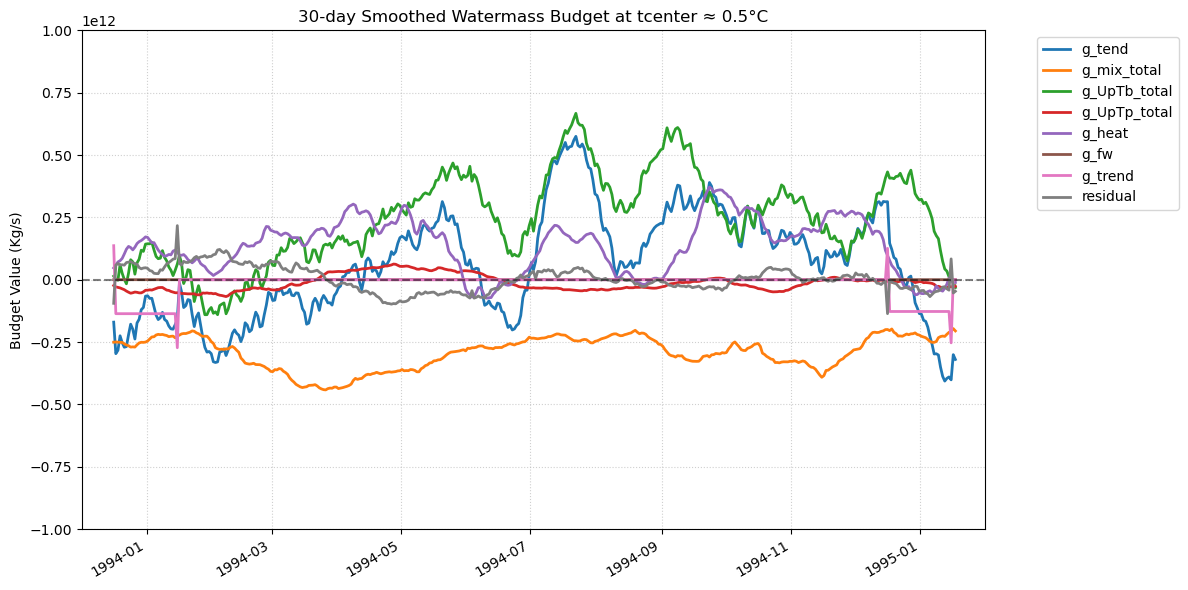

In [9]:
import matplotlib.pyplot as plt
import xarray as xr

# --- 1. 选择特定的温度层 ---
target_temp = 0.5 
ts_layer = combined.sel(tcenter=target_temp, method="nearest")

# --- 2. 计算残差 (建议在平滑前计算，保证物理闭合性的一致性) ---
ts_layer["residual"] = (
    ts_layer["g_tend"]
    - sum(ts_layer[v] for v in ts_layer.data_vars if v not in ["g_tend", "residual"])
)

# --- 3. 平滑处理 (30天滑动平均) ---
# center=True 保证平滑后的趋势在时间轴上是对齐的
window_size = 30  # 你可以改成 90 (季) 或 365 (年)
ts_layer_smooth = ts_layer.rolling(time=window_size, center=True).mean()

# --- 4. 绘图 ---
plt.figure(figsize=(12, 6))

for var in ts_layer_smooth.data_vars:
    # 绘制平滑后的线条
    plt.plot(ts_layer_smooth.time, ts_layer_smooth[var], label=var, linewidth=2)

plt.axhline(0, color='k', linestyle='--', alpha=0.5)

# 设置 x 轴范围
plt.xlim(ts_layer_smooth.time[0], ts_layer_smooth.time[-1])

# 设置 y 轴范围
plt.ylabel('Budget Value (Kg/s)')
plt.ylim(-1e12, 1e12)

plt.title(f'{window_size}-day Smoothed Watermass Budget at tcenter ≈ {target_temp}°C')

# 自动格式化时间轴
plt.gcf().autofmt_xdate()

# 图例放在右侧
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

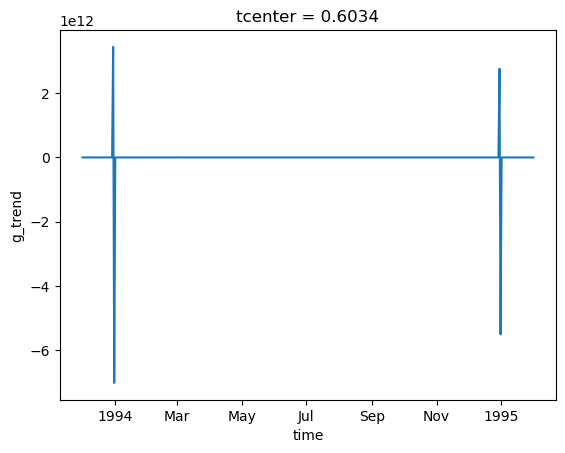

In [19]:
ds["g_trend"].isel(tcenter=95).plot()